# D65 enrollment by building

How Evanston/Skokie School District 65 buildings are used, fall of school year 2026–27 (SY27): enrollment vs. projections, utilization and capacity, building space, attendance-area capture, utility cost, dual-language (TWI) strands, and estimated class sizes.

> **AI assistance:** This analysis was built with help from Claude, Anthropic's AI assistant. Claude can make mistakes, including in transcribing data, in calculations and in interpretation. Please verify figures against the original sources in `sources/` before relying on them.

**Run top to bottom.** Inputs are read from `data/`, tables are written to `data/`, charts to `images/`. Where every number comes from is documented in `sources/sources.md`; definitions and assumptions are in `README.md`.

**Contents**
0. Setup
1. Enrollment by school and grade
2. Projected vs. current enrollment (1A utilization table)
3. Validation against the Cordogan Clark report (PDF), then utilization with Cordogan Clark capacity
4. Enrollment and utilization charts
5. Capacity comparison
6. Building square footage and learning space
7. Attendance-area capture
8. Utility cost per student and per seat
9. Dual-language (TWI) strands
10. Estimated classes and class size
11. Enrollment table with TWI breakouts
12. Parent-reported class sizes compared with the estimates

**Estimates to know about:** class counts are estimated (cap of 24, TWI and ACC students spread evenly across K–5); Oakton ACC uses the 73 projected students; building square feet are derived from energy data. See README for details.

In [1]:
# ── Setup: libraries, shared chart style, and helpers used throughout ──────────────
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Shared chart style: light grid, no box, readable type
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#0b0b0b',
    'axes.grid': True, 'axes.grid.axis': 'x', 'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
})

# Colors: one blue ramp for data, red only for "below projection", grays for text
BLUE, ORANGE, INK, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'
LIGHT_BLUE, DARK_BLUE = '#b7d3f6', '#184f95'     # projected = light, actual = dark
RED = '#e34948'

def short(name):
    """Shorter school labels for charts and tables, e.g. 'Dawes Elementary School' -> 'Dawes'."""
    return (name.replace('Dr Martin Luther King Jr Literary & Fine Arts School', 'King Arts')
                .replace(' Elementary School', '').replace(' Middle School', ' (MS)').replace(' School', ''))


In [2]:
# Dashboard home-page data by school: one row per chart value (grade, IEP, EL, TWI, race, incidents)
df = pd.read_csv('data/students_home_demographics.csv')
df.head()

,school,chart_id,chart_title,series,category,value
0,District,home-iep,IEP Status,NaN,Has IEP,953.0
1,District,home-iep,IEP Status,NaN,No IEP,4509.0
2,District,home-lep,EL Status,NaN,EL,775.0
3,District,home-lep,EL Status,NaN,Not EL,4687.0
4,District,home-race,Race/Ethnicity,NaN,Asian,240.0


# 1. Enrollment by school and grade

## Keep grade rows for schools

In [3]:
# Keep the Grade Level chart (home-grade) for grades K-8; set the District row aside for checks
grades = df[df['chart_id'] == 'home-grade'].copy()
grades['grade'] = pd.to_numeric(grades['category'], errors='coerce')
grades = grades[grades['grade'].between(0, 8)]
grades['grade'] = grades['grade'].astype(int)

district = grades[grades['school'] == 'District']
schools = grades[grades['school'] != 'District']
schools[['school', 'grade', 'value']].head(10)

,school,grade,value
42,Chute Middle School,6,184.0
43,Chute Middle School,7,209.0
44,Chute Middle School,8,198.0
60,Dawes Elementary School,0,43.0
61,Dawes Elementary School,1,45.0
62,Dawes Elementary School,2,42.0
63,Dawes Elementary School,3,48.0
64,Dawes Elementary School,4,59.0
65,Dawes Elementary School,5,51.0
84,Dewey Elementary School,0,48.0


## Pivot wider

In [4]:
# One row per school, one column per grade (grade_0 = kindergarten), plus a total
wide = (schools
        .pivot_table(index='school', columns='grade', values='value', aggfunc='sum', fill_value=0)
        .reindex(columns=range(9), fill_value=0)
        .astype(int))
wide.columns.name = None
wide.columns = [f'grade_{g}' for g in wide.columns]   # grade_0 = kindergarten
wide['total'] = wide.sum(axis=1)
wide = wide.sort_index()
wide

,grade_0,grade_1,grade_2,grade_3,grade_4,grade_5,grade_6,grade_7,grade_8,total
school,,,,,,,,,,
Chute Middle School,0,0,0,0,0,0,184,209,198,591
Dawes Elementary School,43,45,42,48,59,51,0,0,0,288
Dewey Elementary School,48,55,45,52,64,51,0,0,0,315
Dr Martin Luther King Jr Literary & Fine Arts School,41,40,37,56,54,46,43,67,61,445
Foster School,46,42,65,79,57,72,0,0,0,361
Haven Middle School,0,0,0,0,0,0,181,211,212,604
Lincoln Elementary School,57,73,53,43,68,56,0,0,0,350
Lincolnwood Elementary School,48,60,54,42,48,79,0,0,0,331
Nichols Middle School,0,0,0,0,0,0,195,172,215,582


## Check against the district totals

In [5]:
# Check: schools must add up to the district total in every grade
district_by_grade = district.set_index('grade')['value'].reindex(range(9), fill_value=0)
school_sums = wide.drop(columns='total').sum().values
check = pd.DataFrame({'district': district_by_grade.values, 'sum_of_schools': school_sums}, index=[f'grade_{g}' for g in range(9)])
check['match'] = check['district'] == check['sum_of_schools']
print('Total students:', wide['total'].sum())
check

Total students: 5462


,district,sum_of_schools,match
grade_0,534.0,534,True
grade_1,564.0,564,True
grade_2,545.0,545,True
grade_3,606.0,606,True
grade_4,620.0,620,True
grade_5,645.0,645,True
grade_6,603.0,603,True
grade_7,659.0,659,True
grade_8,686.0,686,True


In [6]:
# Save the school x grade enrollment table
wide.to_csv('data/enrollment_by_school_grade.csv')

# 2. Compare with the 1A Utilization table

`utilization_1A_website.csv` was transcribed from a screenshot of the district's *1A_Utilization_website* table. Its **Enroll Total** is the district's *projected* enrollment. It is compared here with this year's dashboard enrollment (`total` above). **Enroll SY25** is included for reference.

In [7]:
# 1A utilization table (typed in from the district screenshot); align King Arts spelling with the dashboard
util = pd.read_csv('data/utilization_1A_website.csv')
# match the dashboard's spelling of King Arts
util['school'] = util['school'].str.replace('Dr. Martin Luther King Jr.', 'Dr Martin Luther King Jr', regex=False)
util.head()

,school,enroll_sy25,area_counts,cap_total,cap_neighb,cap_twi,cap_acc,enroll_total,enroll_neighb,enroll_twe,enroll_tws,enroll_twx,enroll_acc,util_total_pct
0,Dawes Elementary School,294,354,432,288,144,0,337,186,60,61,30,0,78.0
1,Dewey Elementary School,316,442,576,432,144,0,372,260,48,39,25,0,65.0
2,Kingsley Elementary School,326,0,0,0,0,0,0,0,0,0,0,0,NaN
3,Lincoln Elementary School,334,476,576,576,0,0,328,328,0,0,0,0,57.0
4,Lincolnwood Elementary School,283,297,432,432,0,0,280,280,0,0,0,0,65.0


In [8]:
# Current (dashboard) vs. projected (1A 'Enroll Total') enrollment, school by school
cmp = (util.set_index('school')[['enroll_sy25', 'enroll_total', 'cap_total']]
       .join(wide[['total']].rename(columns={'total': 'dashboard_sy27'}), how='outer'))
cmp['diff_vs_enroll_total'] = cmp['dashboard_sy27'] - cmp['enroll_total']
cmp['pct_diff'] = (100 * cmp['diff_vs_enroll_total'] / cmp['enroll_total']).round(1)
cmp['util_pct_dashboard'] = (100 * cmp['dashboard_sy27'] / cmp['cap_total']).round(0)

matched = cmp.dropna(subset=['dashboard_sy27']).sort_values('pct_diff')
matched

,enroll_sy25,enroll_total,cap_total,dashboard_sy27,diff_vs_enroll_total,pct_diff,util_pct_dashboard
school,,,,,,,
Foster School,0,452,576,361.0,-91.0,-20.1,63.0
Dewey Elementary School,316,372,576,315.0,-57.0,-15.3,55.0
Dawes Elementary School,294,337,432,288.0,-49.0,-14.5,67.0
Washington Elementary School,403,441,530,387.0,-54.0,-12.2,73.0
Nichols Middle School,609,656,705,582.0,-74.0,-11.3,83.0
Haven Middle School,642,664,936,604.0,-60.0,-9.0,65.0
Oakton Elementary School,361,403,576,367.0,-36.0,-8.9,64.0
Walker Elementary School,345,304,432,317.0,13.0,4.3,73.0
Willard Elementary School,345,261,576,273.0,12.0,4.6,47.0


Schools on the utilization table that aren't on the dashboard (closed schools, early childhood programs, JEH, out-of-district):

In [9]:
# Rows in the 1A table with no dashboard match (closed schools, early childhood, JEH, out of district)
cmp[cmp['dashboard_sy27'].isna()][['enroll_sy25', 'enroll_total', 'cap_total']]

,enroll_sy25,enroll_total,cap_total
school,,,
Dr. Bessie Rhodes School of Global Studies,251,0,0
Family Center,34,34,60
Joseph E. Hill Education Center,242,242,404
Kingsley Elementary School,326,0,0
Not in D65,0,19,0
Park School,57,57,109
Rice Children's Center,19,19,0


In [10]:
# Totals for the schools in both sources
tot = matched[['enroll_sy25', 'enroll_total', 'dashboard_sy27']].sum()
print(tot)
print(f"Dashboard vs Enroll Total, same 14 schools: {tot.dashboard_sy27 - tot.enroll_total:+.0f} students ({100*(tot.dashboard_sy27/tot.enroll_total-1):+.1f}%)")

enroll_sy25       5132.0
enroll_total      5690.0
dashboard_sy27    5462.0
dtype: float64
Dashboard vs Enroll Total, same 14 schools: -228 students (-4.0%)


In [11]:
# Save the projected vs. current comparison
matched.to_csv('data/enrollment_vs_utilization.csv')

# 3. Current utilization using Cordogan Clark capacity

`capacity_cordogan_clark.csv` was transcribed from a screenshot of the capacity table that has Cordogan Clark's floor-plan counts. The green **Util Total** column there is the *predicted* utilization: projected Enroll Total ÷ Cap Total.

Current utilization = this year's dashboard enrollment ÷ the **smaller** of Cap Total (baseline) and Cordogan Clark capacity. The screenshot stops at King Arts, so Chute, Haven and Nichols take Cap Total, projected Enroll Total and Util % from the 1A Utilization table, and their Cordogan Clark capacity from the Cordogan Clark report itself (`cordogan_clark_2022_report.csv`, transcribed from the February 2022 PDF).

## Validation: screenshot vs. the Cordogan Clark report (PDF)

`cordogan_clark_2022_report.csv` is transcribed from *Space Guidelines, Building Capacity & Space Utilization Report for Evanston/Skokie School District No. 65* (Cordogan Clark, February 14, 2022; `sources/`). This cell checks that the Cordogan figures typed in from the capacity screenshot match the report exactly: classroom square feet, teaching stations and capacity.

- **Foster isn't in the report** (it wasn't operating as a school in 2021–22), so its Cordogan figures in the screenshot can't be checked against it.
- **Floor-plan classrooms, offices, FAPEL and the other room counts** in the screenshot are the district's own review, not the report's.
- The report's enrollment and utilization columns are **2021–22** figures and aren't used in this analysis.

In [12]:
# Cordogan Clark report (Feb 2022 PDF): one row per school from its summary pages
report = pd.read_csv('data/cordogan_clark_2022_report.csv').set_index('school')

shot = pd.read_csv('data/capacity_cordogan_clark.csv').dropna(subset=['cap_total_baseline']).set_index('school')
both = shot.index.intersection(report.index)

check = pd.DataFrame({
    'sf_screenshot': shot.loc[both, 'total_sf_core_classrooms_sped'], 'sf_report': report.loc[both, 'total_sf_core_sped'],
    'stations_screenshot': shot.loc[both, 'teaching_stations'], 'stations_report': report.loc[both, 'teaching_stations'],
    'capacity_screenshot': shot.loc[both, 'capacity_cordogan'], 'capacity_report': report.loc[both, 'capacity'],
}).astype(int)
check['all_match'] = ((check.sf_screenshot == check.sf_report) & (check.stations_screenshot == check.stations_report)
                      & (check.capacity_screenshot == check.capacity_report))
assert check['all_match'].all(), 'screenshot and report disagree - see table'
print(f"{len(both)} schools checked: every Cordogan figure in the screenshot matches the report.")
print('In the screenshot but not the report:', shot.index.difference(report.index).tolist())

# District capacity (1A table "Cap Total") vs. the report's Cordogan capacity, for buildings only the 1A table has
cap_1a = util.set_index('school')['cap_total']
for s_1a, s_rep in [('Chute Middle School',) * 2, ('Haven Middle School',) * 2, ('Nichols Middle School',) * 2,
                    ('Park School',) * 2, ('Joseph E. Hill Education Center',) * 2]:
    print(f"  {s_1a}: 1A Cap Total {cap_1a[s_1a]:.0f} vs. report capacity {report.loc[s_rep, 'capacity']}")
check

11 schools checked: every Cordogan figure in the screenshot matches the report.
In the screenshot but not the report: ['Foster School']
  Chute Middle School: 1A Cap Total 792 vs. report capacity 792
  Haven Middle School: 1A Cap Total 936 vs. report capacity 937
  Nichols Middle School: 1A Cap Total 705 vs. report capacity 705
  Park School: 1A Cap Total 109 vs. report capacity 109
  Joseph E. Hill Education Center: 1A Cap Total 404 vs. report capacity 464


,sf_screenshot,sf_report,stations_screenshot,stations_report,capacity_screenshot,capacity_report,all_match
school,,,,,,,
Dawes Elementary School,19398,19398,19,19,501,501,True
Dewey Elementary School,20248,20248,24,24,537,537,True
Kingsley Elementary School,16915,16915,20,20,435,435,True
Lincoln Elementary School,25502,25502,27,27,642,642,True
Lincolnwood Elementary School,19410,19410,19,19,508,508,True
Oakton Elementary School,18360,18360,26,26,467,467,True
Orrington Elementary School,18061,18061,20,20,464,464,True
Walker Elementary School,17312,17312,18,18,467,467,True
Washington Elementary School,23872,23872,24,24,626,626,True


In [13]:
# Capacity used = smaller of Cap Total and Cordogan Clark; current utilization = dashboard enrollment / that
cc = pd.read_csv('data/capacity_cordogan_clark.csv').dropna(subset=['cap_total_baseline'])
cc = cc.set_index('school')[['cap_total_baseline', 'capacity_cordogan', 'enroll_total', 'util_total_pct_predicted']]

# Middle schools aren't in the Cordogan screenshot: take Cap Total, projected Enroll Total and Util % from the 1A table,
# and their Cordogan capacity from the Cordogan Clark report (PDF)
ms = ['Chute Middle School', 'Haven Middle School', 'Nichols Middle School']
ms_rows = (util.set_index('school').loc[ms, ['cap_total', 'enroll_total', 'util_total_pct']]
           .rename(columns={'cap_total': 'cap_total_baseline', 'util_total_pct': 'util_total_pct_predicted'}))
cc = pd.concat([cc, ms_rows])
cc.loc[ms, 'capacity_cordogan'] = report.loc[ms, 'capacity']
cc['capacity_used'] = cc[['cap_total_baseline', 'capacity_cordogan']].min(axis=1)
cc['capacity_source'] = (cc['capacity_cordogan'] < cc['cap_total_baseline']).map({True: 'Cordogan', False: 'Cap Total'})
cc.loc[cc['capacity_cordogan'].isna(), 'capacity_source'] = 'Cap Total (no Cordogan count)'
cc.loc[ms, 'capacity_source'] = cc.loc[ms, 'capacity_source'] + ' (1A table)'

cc = cc.join(wide[['total']].rename(columns={'total': 'dashboard_sy27'}))
cc['util_pct_current'] = (100 * cc['dashboard_sy27'] / cc['capacity_used']).round(0)
cc['util_change_pts'] = cc['util_pct_current'] - cc['util_total_pct_predicted']
cc

,cap_total_baseline,capacity_cordogan,enroll_total,util_total_pct_predicted,capacity_used,capacity_source,dashboard_sy27,util_pct_current,util_change_pts
school,,,,,,,,,
Dawes Elementary School,432.0,501.0,337.0,78.0,432.0,Cap Total,288.0,67.0,-11.0
Dewey Elementary School,576.0,537.0,372.0,65.0,537.0,Cordogan,315.0,59.0,-6.0
Kingsley Elementary School,432.0,435.0,167.0,39.0,432.0,Cap Total,NaN,NaN,NaN
Lincoln Elementary School,576.0,642.0,328.0,57.0,576.0,Cap Total,350.0,61.0,4.0
Lincolnwood Elementary School,432.0,508.0,181.0,42.0,432.0,Cap Total,331.0,77.0,35.0
Oakton Elementary School,576.0,467.0,403.0,70.0,467.0,Cordogan,367.0,79.0,9.0
Orrington Elementary School,432.0,464.0,226.0,52.0,432.0,Cap Total,251.0,58.0,6.0
Walker Elementary School,432.0,467.0,304.0,70.0,432.0,Cap Total,317.0,73.0,3.0
Washington Elementary School,530.0,626.0,441.0,83.0,530.0,Cap Total,387.0,73.0,-10.0


In [14]:
# Save current vs. predicted utilization
cc.to_csv('data/utilization_current_vs_predicted.csv')

# 4. Enrollment and utilization charts

## Projected vs. current enrollment

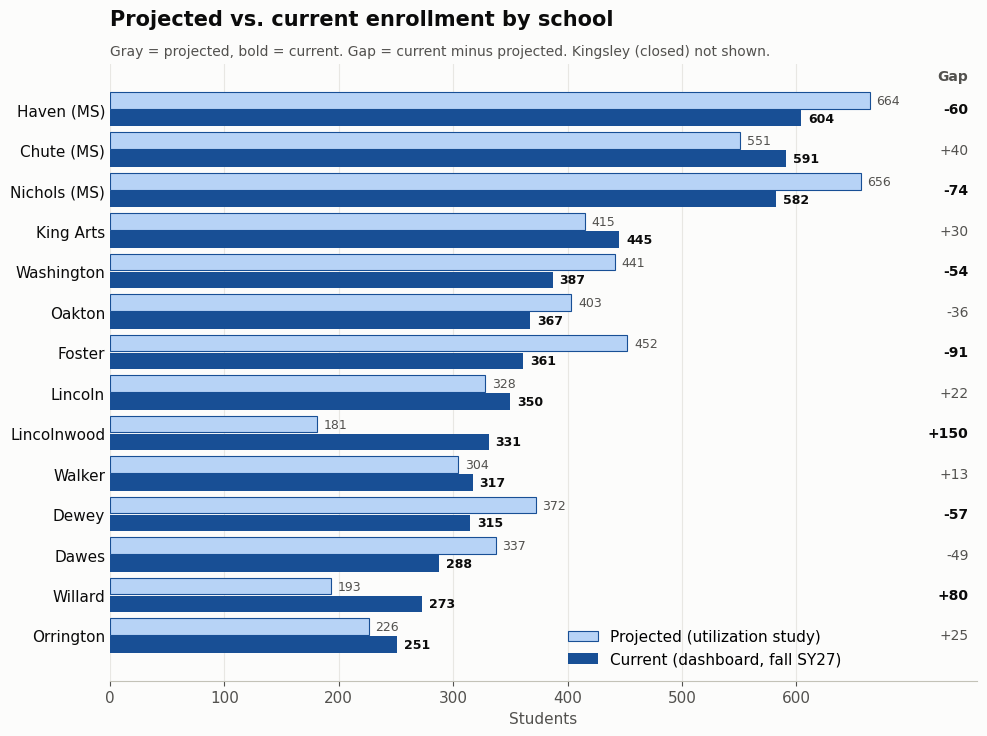

In [15]:
# Paired bars: projected (light) vs. current (dark) enrollment, with the gap in its own column
enr = cc.dropna(subset=['dashboard_sy27'])[['enroll_total', 'dashboard_sy27']].copy()
enr.index = enr.index.map(short)
enr = enr.sort_values('dashboard_sy27')

y = np.arange(len(enr))
h = 0.44
fig, ax = plt.subplots(figsize=(10, 7.5))
b_proj = ax.barh(y + h/2, enr['enroll_total'], height=h - 0.03, color=LIGHT_BLUE, edgecolor=DARK_BLUE, linewidth=0.8, label='Projected (utilization study)')
b_cur = ax.barh(y - h/2, enr['dashboard_sy27'], height=h - 0.03, color=DARK_BLUE, label='Current (dashboard, fall SY27)')

xmax = enr.values.max()
gap_x = xmax * 1.13   # gap numbers sit in their own column at the right

for yi, (proj, cur) in zip(y, enr[['enroll_total', 'dashboard_sy27']].values):
    # projected total at the end of the light bar
    ax.text(proj + 6, yi + h/2, f'{proj:.0f}', va='center', fontsize=9, color=MUTED)
    # current total at the end of the dark bar
    ax.text(cur + 6, yi - h/2, f'{cur:.0f}', va='center', fontsize=9, color=INK, fontweight='bold')
    # gap in the right-hand column
    d = cur - proj
    ax.text(gap_x, yi, f'{d:+.0f}', va='center', ha='right', fontsize=10,
            color=INK if abs(d) >= 50 else MUTED, fontweight='bold' if abs(d) >= 50 else 'normal')
ax.text(gap_x, len(enr) - 0.35, 'Gap', ha='right', va='bottom', fontsize=10, color=MUTED, fontweight='bold')

ax.set_yticks(y, enr.index)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Students')
ax.set_xlim(0, gap_x * 1.01)
ax.set_xticks(range(0, int(xmax) + 1, 100))
ax.set_title('Projected vs. current enrollment by school', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Gray = projected, bold = current. Gap = current minus projected. Kingsley (closed) not shown.',
        transform=ax.transAxes, fontsize=10, color=MUTED)
ax.legend(handles=[b_proj, b_cur], loc='lower right', bbox_to_anchor=(0.86, 0), frameon=False)  # same order as the bars
plt.tight_layout()
fig.savefig('images/chart_projected_vs_current_enrollment.png', dpi=200)
plt.show()

## Difference from projection, largest first

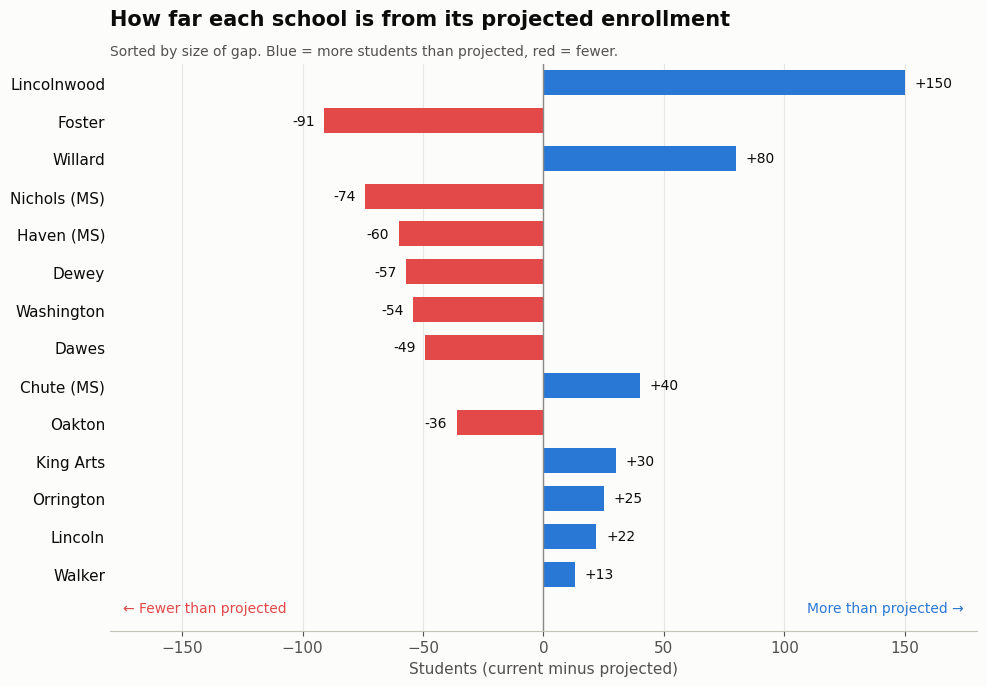

In [16]:
# Chart: current minus projected enrollment, biggest gap first (blue = above projection, red = below)
diff = (enr['dashboard_sy27'] - enr['enroll_total']).rename('diff').to_frame()
diff = diff.reindex(diff['diff'].abs().sort_values().index)   # biggest gap at the top

fig, ax = plt.subplots(figsize=(10, 7))
colors = [BLUE if d > 0 else RED for d in diff['diff']]
ax.barh(diff.index, diff['diff'], color=colors, height=0.66)
ax.axvline(0, color='#8a8984', linewidth=1)

pad = 4
for yi, d in enumerate(diff['diff']):
    ax.text(d + (pad if d > 0 else -pad), yi, f'{d:+.0f}', va='center',
            ha='left' if d > 0 else 'right', fontsize=10, color=INK)

lim = diff['diff'].abs().max() * 1.2
ax.set_xlim(-lim, lim)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Students (current minus projected)')
ax.set_title('How far each school is from its projected enrollment', loc='left', fontsize=15,
             fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Sorted by size of gap. Blue = more students than projected, red = fewer.',
        transform=ax.transAxes, fontsize=10, color=MUTED)
ax.text(lim * 0.97, -0.9, 'More than projected →', ha='right', va='center', fontsize=10, color=BLUE)
ax.text(-lim * 0.97, -0.9, '← Fewer than projected', ha='left', va='center', fontsize=10, color=RED)
ax.set_ylim(-1.5, len(diff) - 0.5)
plt.tight_layout()
fig.savefig('images/chart_enrollment_difference.png', dpi=200)
plt.show()

## Predicted vs. current utilization

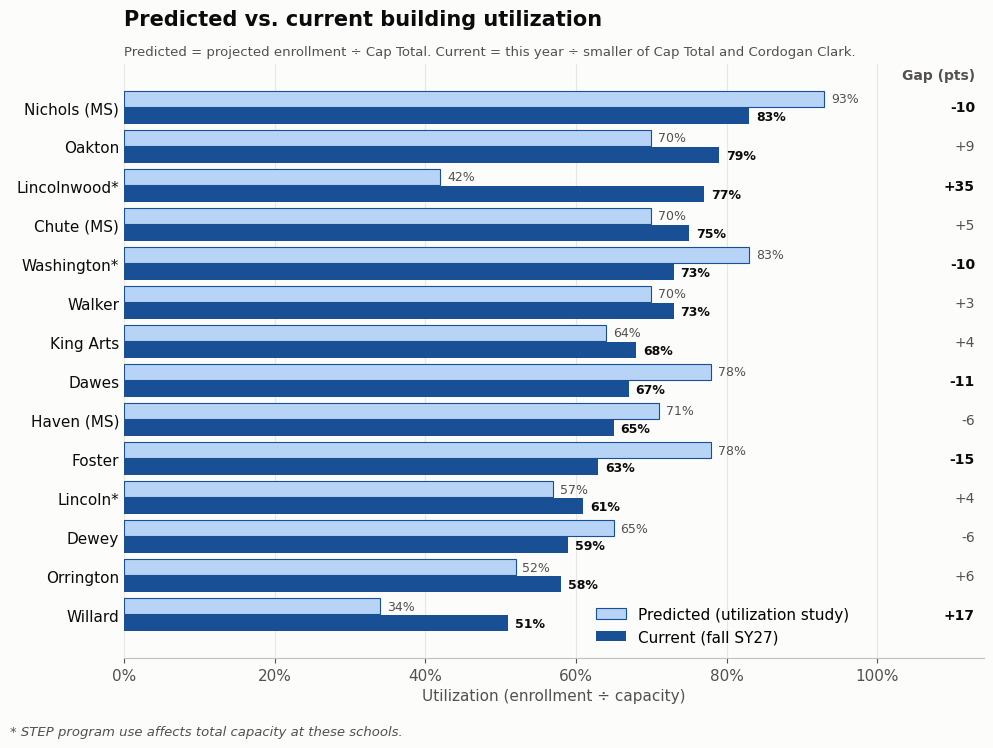

In [17]:
# Chart: predicted vs. current utilization; STEP schools get an asterisk
ut = cc.dropna(subset=['util_pct_current'])[['util_total_pct_predicted', 'util_pct_current', 'capacity_used']].copy()
ut.index = ut.index.map(short)
STEP = {'Lincoln', 'Lincolnwood', 'Washington'}   # STEP use affects their capacity
ut.index = [f'{n}*' if n in STEP else n for n in ut.index]
ut = ut.sort_values('util_pct_current')

y = np.arange(len(ut))
h = 0.44
fig, ax = plt.subplots(figsize=(10, 7.5))
b_pred = ax.barh(y + h/2, ut['util_total_pct_predicted'], height=h - 0.03, color=LIGHT_BLUE,
                 edgecolor=DARK_BLUE, linewidth=0.8, label='Predicted (utilization study)')
b_now = ax.barh(y - h/2, ut['util_pct_current'], height=h - 0.03, color=DARK_BLUE, label='Current (fall SY27)')

gap_x = 100 * 1.13
for yi, (pred, now) in zip(y, ut[['util_total_pct_predicted', 'util_pct_current']].values):
    ax.text(pred + 0.9, yi + h/2, f'{pred:.0f}%', va='center', fontsize=9, color=MUTED)
    ax.text(now + 0.9, yi - h/2, f'{now:.0f}%', va='center', fontsize=9, color=INK, fontweight='bold')
    d = now - pred
    ax.text(gap_x, yi, f'{d:+.0f}', va='center', ha='right', fontsize=10,
            color=INK if abs(d) >= 10 else MUTED, fontweight='bold' if abs(d) >= 10 else 'normal')
ax.text(gap_x, len(ut) - 0.35, 'Gap (pts)', ha='right', va='bottom', fontsize=10, color=MUTED, fontweight='bold')

ax.set_yticks(y, ut.index)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, gap_x * 1.01)
ax.set_xticks(range(0, 101, 20), [f'{t}%' for t in range(0, 101, 20)])
ax.set_xlabel('Utilization (enrollment ÷ capacity)')
ax.set_title('Predicted vs. current building utilization', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Predicted = projected enrollment ÷ Cap Total. Current = this year ÷ smaller of Cap Total and Cordogan Clark.',
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.legend(handles=[b_pred, b_now], loc='lower right', bbox_to_anchor=(0.86, 0), frameon=False)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.text(0.01, 0.01, '* STEP program use affects total capacity at these schools.', fontsize=9.5, color=MUTED, style='italic')
fig.savefig('images/chart_utilization_predicted_vs_current.png', dpi=200)
plt.show()

## Current utilization

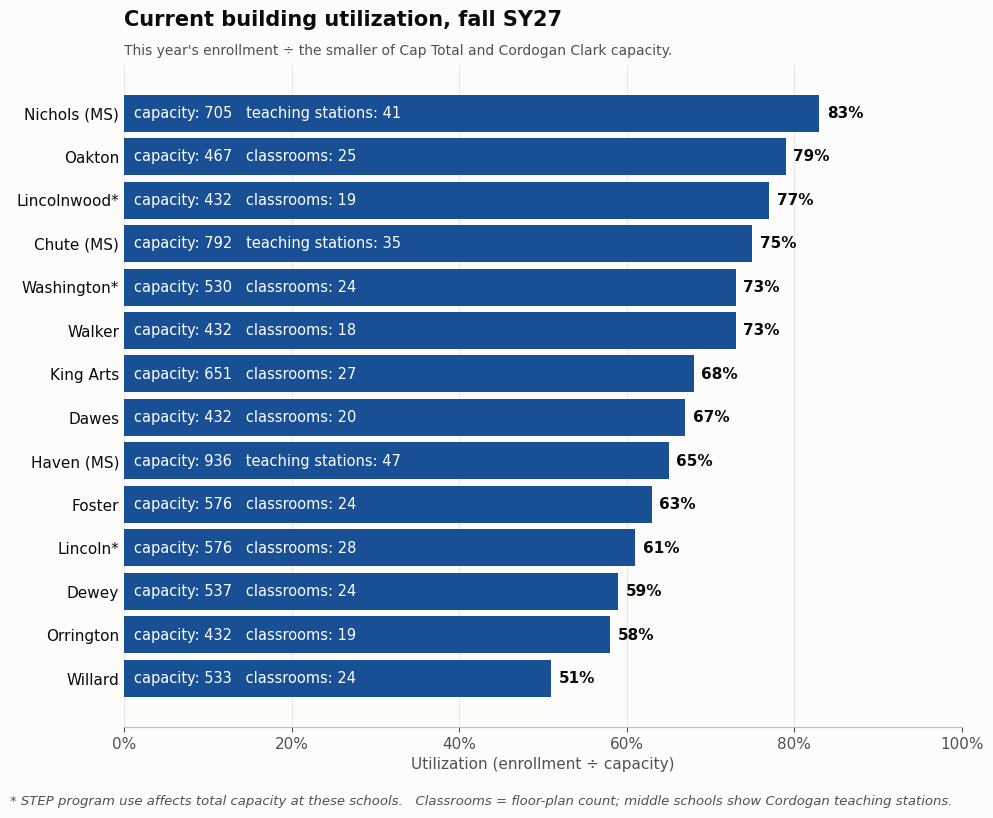

In [18]:
# Chart: current utilization only, with capacity and classrooms written in each bar
cur = ut['util_pct_current'].sort_values()
cap = ut['capacity_used'].reindex(cur.index)

# Classrooms: Cordogan Clark floor-plan classroom count; Foster has none on the floor-plan column,
# so its Cordogan teaching-station count is used. Middle schools have no floor-plan count, so they show
# Cordogan Clark teaching stations from the report instead (core classrooms + science labs + SPED).
rooms_src = pd.read_csv('data/capacity_cordogan_clark.csv').set_index('school')
rooms_src = rooms_src['floor_plan_classrooms'].fillna(rooms_src['teaching_stations'])
rooms_src.index = [f'{short(i)}*' if short(i) in STEP else short(i) for i in rooms_src.index]
rooms = rooms_src.reindex(cur.index)
ms_stations = report.loc[ms, 'teaching_stations'].rename(index=short).reindex(cur.index)

fig, ax = plt.subplots(figsize=(10, 8.2))
ax.barh(cur.index, cur.values, height=0.85, color=DARK_BLUE)
for yi, (v, k) in enumerate(zip(cur.values, cap.values)):
    ax.text(v + 0.9, yi, f'{v:.0f}%', va='center', fontsize=11, color=INK, fontweight='bold')
    if pd.notna(rooms.iloc[yi]):
        extra = f'   classrooms: {rooms.iloc[yi]:.0f}'
    elif pd.notna(ms_stations.iloc[yi]):
        extra = f'   teaching stations: {ms_stations.iloc[yi]:.0f}'
    else:
        extra = ''
    inside = f'capacity: {k:.0f}' + extra
    ax.text(1.2, yi, inside, va='center', ha='left', fontsize=10.5, color='white')

ax.tick_params(axis='y', length=0)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 20), [f'{t}%' for t in range(0, 101, 20)])
ax.set_xlabel('Utilization (enrollment ÷ capacity)')
ax.set_title('Current building utilization, fall SY27', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'This year\'s enrollment ÷ the smaller of Cap Total and Cordogan Clark capacity.',
        transform=ax.transAxes, fontsize=10, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.text(0.01, 0.01, '* STEP program use affects total capacity at these schools.   Classrooms = floor-plan count; middle schools show Cordogan teaching stations.', fontsize=9.5, color=MUTED, style='italic')
fig.savefig('images/chart_utilization_current.png', dpi=200)
plt.show()

# 5. Capacity comparison table

Every capacity figure we have for each school, and which one the utilization charts use (the smaller of Cap Total and Cordogan Clark).

- **District teaching stations**: "Calculated Teaching Stations"; Cap Total = 24 × this
- **Cordogan teaching stations** and **classrooms (floor plan)** are from Cordogan Clark
- **24 × / 25 × classrooms**: simple per-room capacities, for comparison

In [19]:
# Every capacity figure per school and which one the utilization charts use (whole numbers)
raw = pd.read_csv('data/capacity_cordogan_clark.csv').dropna(subset=['cap_total_baseline']).set_index('school')

cap_table = pd.DataFrame(index=cc.index)
cap_table['district_teaching_stations'] = raw['calc_teaching_stations']
cap_table['cordogan_teaching_stations'] = raw['teaching_stations']
cap_table.loc[ms, 'cordogan_teaching_stations'] = report.loc[ms, 'teaching_stations']   # from the report (PDF)
cap_table['classrooms_floor_plan'] = raw['floor_plan_classrooms']
cap_table['cap_total'] = cc['cap_total_baseline']
cap_table['cordogan_capacity'] = cc['capacity_cordogan']
classrooms = raw['floor_plan_classrooms'].fillna(raw['teaching_stations'])   # Foster: no floor-plan count
cap_table['classrooms_x24'] = classrooms * 24
cap_table['capacity_used'] = cc['capacity_used']
cap_table['source_used'] = cc['capacity_source']

# whole numbers throughout (nullable Int64 keeps the blanks); Washington's 22.08 stations rounds to 22
num_cols = cap_table.columns.drop('source_used')
cap_table[num_cols] = cap_table[num_cols].round().astype('Int64')

cap_table.index = cap_table.index.map(short)
cap_table.index.name = 'school'
cap_table = cap_table.sort_index()
cap_table.to_csv('data/capacity_comparison.csv')
cap_table.style.format(na_rep='–')

,district_teaching_stations,cordogan_teaching_stations,classrooms_floor_plan,cap_total,cordogan_capacity,classrooms_x24,capacity_used,source_used
school,,,,,,,,
Chute (MS),–,35,–,792,792,–,792,Cap Total (1A table)
Dawes,18,19,20,432,501,480,432,Cap Total
Dewey,24,24,24,576,537,576,537,Cordogan
Foster,–,24,–,576,600,576,576,Cap Total
Haven (MS),–,47,–,936,937,–,936,Cap Total (1A table)
King Arts,–,30,27,651,653,648,651,Cap Total
Kingsley,18,20,20,432,435,480,432,Cap Total
Lincoln,24,27,28,576,642,672,576,Cap Total
Lincolnwood,18,19,19,432,508,456,432,Cap Total


# 6. Building square footage

The dashboard doesn't publish square feet, but its Sustainability page gives each building's annual energy use (MMBtu) and Energy Use Intensity (kBtu per sq ft). Square feet = energy × 1,000 ÷ EUI. The result is steady across years (2018 and 2025 agree within ~20 sq ft); EUI is rounded to 2 decimals, so treat these as ±a few hundred sq ft. Foster has no utility account on the dashboard.

In [20]:
# Building square feet = (electric + gas MMBtu) x 1,000 / EUI (kBtu per sq ft); 2018 is used as a cross-check
util_raw = pd.read_csv('data/sustainability_utility.csv')
util_raw['category'] = util_raw['category'].astype(str)   # years are stored as text in this mixed column
YEAR = 2025   # last full calendar year

energy = (util_raw[(util_raw.chart_id == 'global-use') & (util_raw.category == str(YEAR))]
          .groupby('account')['value'].sum())            # electric + natural gas, MMBtu
eui = util_raw[(util_raw.chart_id == 'eui') & (util_raw.category == str(YEAR))].set_index('account')['value']
sqft = (energy * 1000 / eui).round(-1).drop('All', errors='ignore').rename('square_feet')

# check: 2018 gives the same answer
e18 = util_raw[(util_raw.chart_id == 'global-use') & (util_raw.category == '2018')].groupby('account')['value'].sum()
u18 = util_raw[(util_raw.chart_id == 'eui') & (util_raw.category == '2018')].set_index('account')['value']
print('max difference 2025 vs 2018:', round((sqft - (e18 * 1000 / u18).drop('All', errors='ignore')).abs().max()), 'sq ft')

sqft.sort_values(ascending=False).to_frame().to_csv('data/building_square_feet.csv')
sqft.sort_values(ascending=False).to_frame()

max difference 2025 vs 2018: 23 sq ft


,square_feet
account,
Haven,142130.0
Chute,112900.0
King Arts,100010.0
Nichols,97880.0
Oakton,95480.0
Washington,76800.0
Lincoln,73440.0
JEH,71010.0
Dewey,65170.0


## Learning space as a share of the building

Learning space = Cordogan Clark's "Total SF Core Classrooms + SPED" (capacity table). Building square feet = the energy-dashboard estimate above. Middle schools aren't in the Cordogan table; Foster has no building square footage.

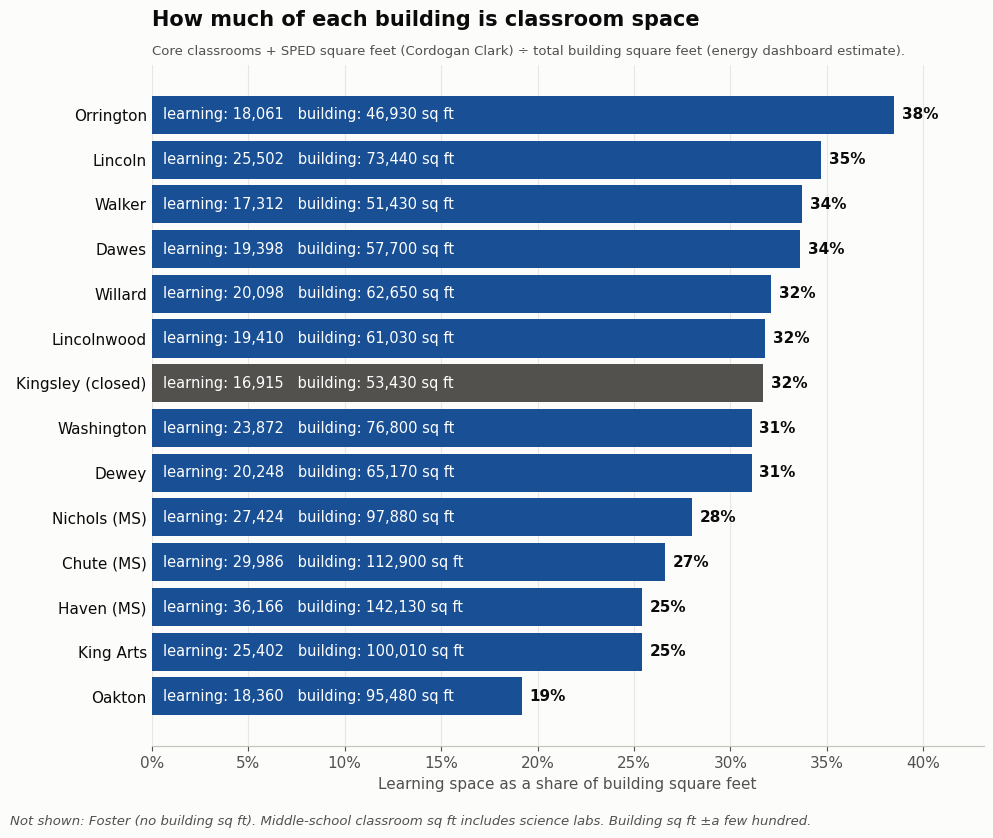

In [21]:
# Chart: classroom square feet (Cordogan core classrooms + SPED) as a share of building square feet
learn = pd.read_csv('data/capacity_cordogan_clark.csv').dropna(subset=['total_sf_core_classrooms_sped'])
learn = learn.set_index(learn['school'].map(short))['total_sf_core_classrooms_sped'].rename('learning_sqft')
# middle schools from the Cordogan Clark report (their classroom sq ft includes science labs)
learn = pd.concat([learn, report.loc[ms, 'total_sf_core_sped'].rename(index=short).rename('learning_sqft')])
learn = learn.rename(index={'Kingsley': 'Kingsley (closed)'})
bldg = sqft.rename(index={'Kingsley': 'Kingsley (closed)', 'Chute': 'Chute (MS)', 'Haven': 'Haven (MS)',
                           'Nichols': 'Nichols (MS)'}).rename('building_sqft')

ls = learn.to_frame().join(bldg, how='left')
no_bldg = ls[ls['building_sqft'].isna()].index.tolist()
ls = ls.dropna()
ls['pct_learning'] = (100 * ls['learning_sqft'] / ls['building_sqft']).round(1)
ls = ls.sort_values('pct_learning')

fig, ax = plt.subplots(figsize=(10, 8.4))
ax.barh(ls.index, ls['pct_learning'], height=0.85,
        color=[MUTED if 'closed' in i else DARK_BLUE for i in ls.index])
for yi, (pct, l, b) in enumerate(ls[['pct_learning', 'learning_sqft', 'building_sqft']].values):
    ax.text(pct + 0.4, yi, f'{pct:.0f}%', va='center', fontsize=11, color=INK, fontweight='bold')
    ax.text(0.6, yi, f'learning: {l:,.0f}   building: {b:,.0f} sq ft', va='center', ha='left', fontsize=10.5, color='white')

ax.tick_params(axis='y', length=0)
ax.set_xlim(0, ls['pct_learning'].max() * 1.12)
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')
ax.set_xlabel('Learning space as a share of building square feet')
ax.set_title('How much of each building is classroom space', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Core classrooms + SPED square feet (Cordogan Clark) ÷ total building square feet (energy dashboard estimate).',
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.text(0.01, 0.01, f"Not shown: {', '.join(no_bldg)} (no building sq ft). Middle-school classroom sq ft includes science labs. Building sq ft ±a few hundred.",
         fontsize=9.5, color=MUTED, style='italic')
fig.savefig('images/chart_learning_space_share.png', dpi=200)
plt.show()

# 7. Attendance-area capture

**Area Counts** (1A utilization table) = students who live in each school's attendance area. Comparing that to who actually enrolls shows which buildings draw students in and which lose them to transfers, magnets and programs.

- **Total capture** = current enrollment ÷ area count; over 100% means the school draws from outside its area
- **Neighborhood capture** = current enrollment minus dual-language (TWI) students ÷ area count; closer to "how many local kids stay" (Oakton's ACC students are still in the neighborhood number)

King Arts has no attendance area (magnet), so it isn't included.

In [22]:
# Attendance-area capture: students living in each area (1A 'Area Counts') vs. enrolled now
twi_now = df[df['chart_id'] == 'home-twi'].groupby('school')['value'].sum()
twi_now.index = twi_now.index.map(short)

area = util.set_index('school')[['area_counts', 'enroll_total', 'enroll_neighb']]
area = area[(area['area_counts'] > 0) & (area.index != 'Not in D65')]
area.index = area.index.map(short)
cur_total = wide['total'].rename(index=short)

area['current_enrollment'] = cur_total.reindex(area.index)
area['current_twi'] = twi_now.reindex(area.index).fillna(0).astype(int)
area['current_neighborhood'] = area['current_enrollment'] - area['current_twi']
area['capture_total_pct'] = (100 * area['current_enrollment'] / area['area_counts']).round(0)
area['capture_neighborhood_pct'] = (100 * area['current_neighborhood'] / area['area_counts']).round(0)
area = area.sort_values('capture_neighborhood_pct')
area.to_csv('data/attendance_area_capture.csv')

elem = area[~area.index.str.contains('MS')]; ms = area[area.index.str.contains('MS')]
for name, g in [('Elementary', elem), ('Middle', ms)]:
    print(f"{name}: {g.area_counts.sum():.0f} live in attendance areas, {g.current_neighborhood.sum():.0f} enrolled as neighborhood students "
          f"({100*g.current_neighborhood.sum()/g.area_counts.sum():.0f}%)")
area

Elementary: 3972 live in attendance areas, 2554 enrolled as neighborhood students (64%)
Middle: 2052 live in attendance areas, 1777 enrolled as neighborhood students (87%)


,area_counts,enroll_total,enroll_neighb,current_enrollment,current_twi,current_neighborhood,capture_total_pct,capture_neighborhood_pct
school,,,,,,,,
Foster,502,452,255,361,200,161,72.0,32.0
Washington,447,441,230,387,195,192,87.0,43.0
Dewey,442,372,260,315,102,213,71.0,48.0
Dawes,354,337,186,288,114,174,81.0,49.0
Oakton,466,403,243,367,75,292,79.0,63.0
Lincoln,476,328,328,350,0,350,74.0,74.0
Walker,426,304,304,317,0,317,74.0,74.0
Nichols (MS),710,656,648,582,0,582,82.0,82.0
Haven (MS),704,664,652,604,0,604,86.0,86.0


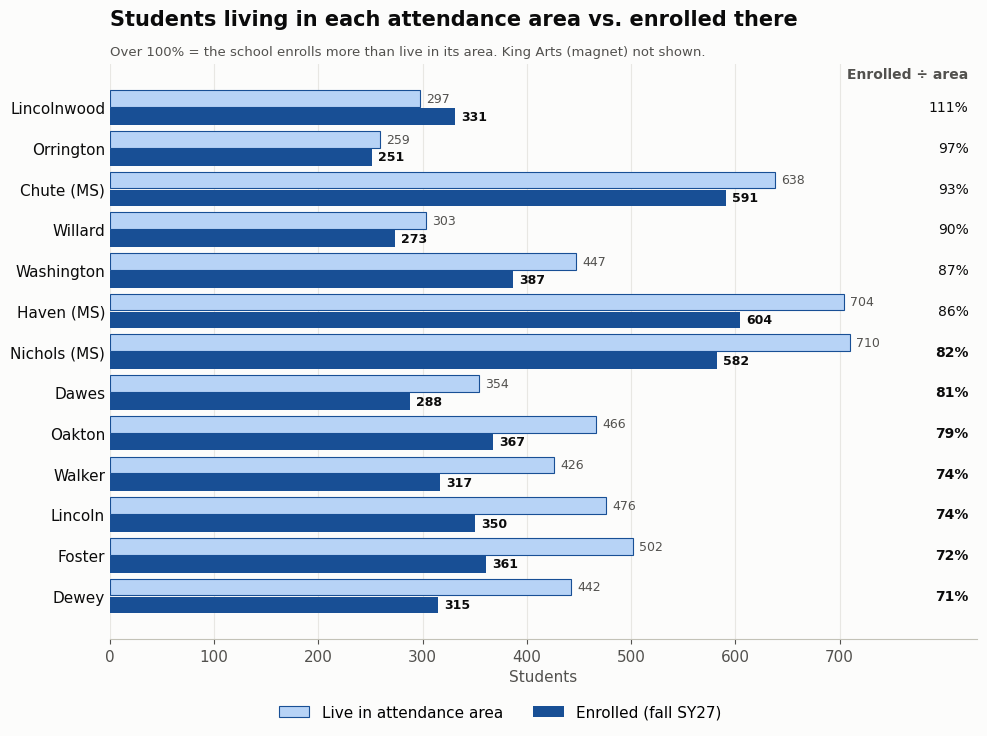

In [23]:
# Chart: students living in each attendance area vs. enrolled
a = area.sort_values('capture_total_pct')
y = np.arange(len(a)); h = 0.44
fig, ax = plt.subplots(figsize=(10, 7.5))
b_area = ax.barh(y + h/2, a['area_counts'], height=h - 0.03, color=LIGHT_BLUE, edgecolor=DARK_BLUE, linewidth=0.8,
                 label='Live in attendance area')
b_enr = ax.barh(y - h/2, a['current_enrollment'], height=h - 0.03, color=DARK_BLUE, label='Enrolled (fall SY27)')
col_x = a[['area_counts', 'current_enrollment']].values.max() * 1.16
for yi, (ar, en, pct) in zip(y, a[['area_counts', 'current_enrollment', 'capture_total_pct']].values):
    ax.text(ar + 6, yi + h/2, f'{ar:.0f}', va='center', fontsize=9, color=MUTED)
    ax.text(en + 6, yi - h/2, f'{en:.0f}', va='center', fontsize=9, color=INK, fontweight='bold')
    ax.text(col_x, yi, f'{pct:.0f}%', va='center', ha='right', fontsize=10, color=INK,
            fontweight='bold' if abs(pct - 100) >= 15 else 'normal')
ax.text(col_x, len(a) - 0.35, 'Enrolled ÷ area', ha='right', va='bottom', fontsize=10, color=MUTED, fontweight='bold')
ax.set_yticks(y, a.index); ax.tick_params(axis='y', length=0)
ax.set_xlim(0, col_x * 1.01)
ax.set_xticks(range(0, int(a[['area_counts', 'current_enrollment']].values.max()) + 1, 100))
ax.set_xlabel('Students')
ax.set_title('Students living in each attendance area vs. enrolled there', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Over 100% = the school enrolls more than live in its area. King Arts (magnet) not shown.',
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
ax.legend(handles=[b_area, b_enr], loc='upper center', bbox_to_anchor=(0.45, -0.09), ncol=2, frameon=False)
plt.tight_layout()
fig.savefig('images/chart_attendance_area_capture.png', dpi=200)
plt.show()

# 8. Utility cost per student and cost of empty seats

Utility cost (electric, natural gas, water) per building from the dashboard's Sustainability page, **calendar 2025** (the last full year; 2026 only runs through August). Enrollment is fall SY27, so this is an approximation.

- **Cost per student** = 2025 utility cost ÷ current enrollment
- **Cost of empty seats** = 2025 utility cost × share of capacity that's empty. It assumes utility cost scales with capacity, which is only roughly true; a half-empty building still heats every hallway.

Foster has no utility account on the dashboard.

In [24]:
# 2025 utility cost per building, per enrolled student, and the share matching empty seats
acct_to_label = {'Chute': 'Chute (MS)', 'Haven': 'Haven (MS)', 'Nichols': 'Nichols (MS)'}
cost25 = (util_raw[(util_raw['chart_id'] == 'cost') & (util_raw['category'] == '2025')]
          .set_index('account')['value'].drop('All', errors='ignore'))
cost25.index = cost25.index.map(lambda a: acct_to_label.get(a, a))

cap_short = cc[['capacity_used']].rename(index=short)['capacity_used']
ce = pd.DataFrame({'utility_cost_2025': cost25.round(0)})
ce['enrollment'] = cur_total.reindex(ce.index)
ce['capacity_used'] = cap_short.reindex(ce.index)
ce['empty_seats'] = ce['capacity_used'] - ce['enrollment']
ce['cost_per_student'] = (ce['utility_cost_2025'] / ce['enrollment']).round(0)
ce['empty_share_pct'] = (100 * ce['empty_seats'] / ce['capacity_used']).round(0)
ce['cost_of_empty_seats'] = (ce['utility_cost_2025'] * ce['empty_seats'] / ce['capacity_used']).round(-2)

schools_ce = ce.dropna(subset=['enrollment']).sort_values('cost_per_student')
other_bldgs = ce[ce['enrollment'].isna()][['utility_cost_2025']]
schools_ce.to_csv('data/utility_cost_per_student.csv')

print(f"Schools: ${schools_ce.utility_cost_2025.sum():,.0f} in 2025 utilities; {schools_ce.empty_seats.sum():.0f} empty seats; "
      f"~${schools_ce.cost_of_empty_seats.sum():,.0f} attributable to empty seats")
print(f"District average: ${schools_ce.utility_cost_2025.sum()/schools_ce.enrollment.sum():,.0f} per student")
print('\nOther buildings (no dashboard enrollment):'); print(other_bldgs.sort_values('utility_cost_2025', ascending=False).to_string())
schools_ce

Schools: $948,812 in 2025 utilities; 2354 empty seats; ~$297,300 attributable to empty seats
District average: $186 per student

Other buildings (no dashboard enrollment):
           utility_cost_2025
account                     
JEH                 168589.0
Kingsley             65300.0
Rhodes               59484.0
Warehouse            48283.0
Park                 43433.0


,utility_cost_2025,enrollment,capacity_used,empty_seats,cost_per_student,empty_share_pct,cost_of_empty_seats
account,,,,,,,
Nichols (MS),82749.0,582.0,705.0,123.0,142.0,17.0,14400.0
Walker,47940.0,317.0,432.0,115.0,151.0,27.0,12800.0
Lincolnwood,50293.0,331.0,432.0,101.0,152.0,23.0,11800.0
Haven (MS),95502.0,604.0,936.0,332.0,158.0,35.0,33900.0
Chute (MS),102362.0,591.0,792.0,201.0,173.0,25.0,26000.0
Orrington,44617.0,251.0,432.0,181.0,178.0,42.0,18700.0
Oakton,66319.0,367.0,467.0,100.0,181.0,21.0,14200.0
Dawes,57663.0,288.0,432.0,144.0,200.0,33.0,19200.0
Dewey,69640.0,315.0,537.0,222.0,221.0,41.0,28800.0


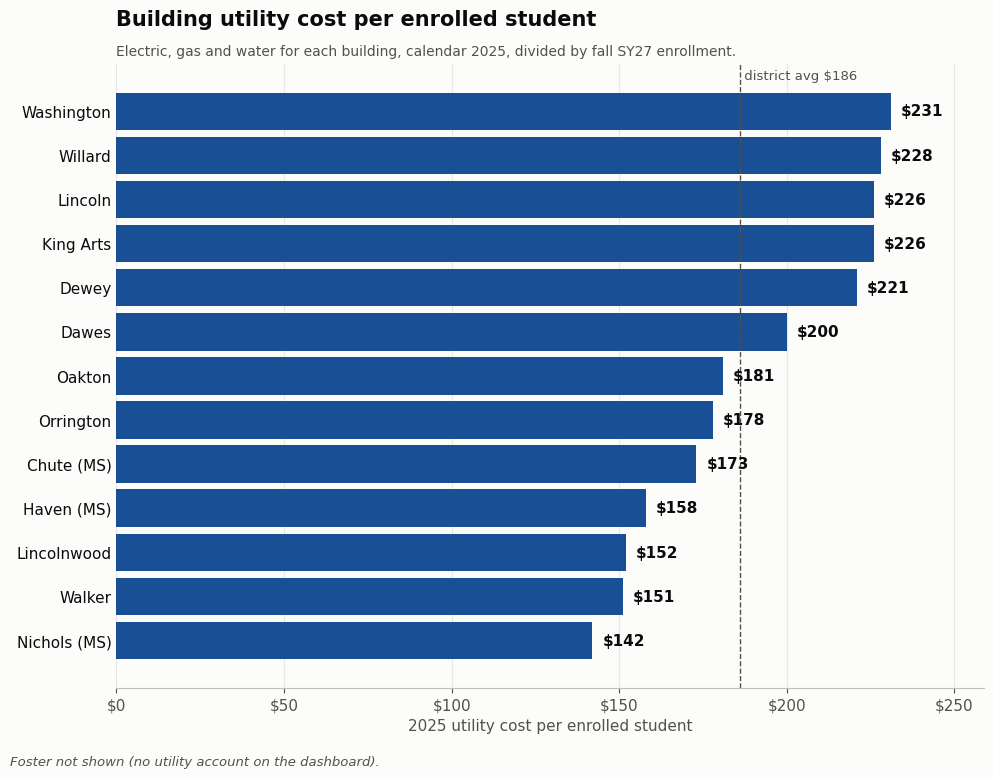

In [25]:
# Chart: 2025 utility cost per enrolled student
c = schools_ce
fig, ax = plt.subplots(figsize=(10, 7.8))
ax.barh(c.index, c['cost_per_student'], height=0.85, color=DARK_BLUE)
for yi, cps in enumerate(c['cost_per_student']):
    ax.text(cps + 3, yi, f'${cps:,.0f}', va='center', fontsize=11, color=INK, fontweight='bold', parse_math=False)
avg = c.utility_cost_2025.sum() / c.enrollment.sum()
ax.axvline(avg, color=MUTED, linewidth=1, linestyle='--')
ax.text(avg, len(c) - 0.35, f' district avg ${avg:,.0f}', va='bottom', fontsize=9.5, color=MUTED, parse_math=False)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, c['cost_per_student'].max() * 1.12)
ax.xaxis.set_major_formatter(lambda v, _: f'${v:,.0f}')
ax.set_xlabel('2025 utility cost per enrolled student')
ax.set_title('Building utility cost per enrolled student', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Electric, gas and water for each building, calendar 2025, divided by fall SY27 enrollment.',
        transform=ax.transAxes, fontsize=10, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.text(0.01, 0.01, 'Foster not shown (no utility account on the dashboard).', fontsize=9.5, color=MUTED, style='italic')
fig.savefig('images/chart_utility_cost_per_student.png', dpi=200)
plt.show()

## Utility cost per seat of capacity

2025 utility cost ÷ capacity used (the smaller of Cap Total and Cordogan Clark). Unlike cost per student, this doesn't depend on how full the building is, so it reflects what each building costs to run for the seats it has.

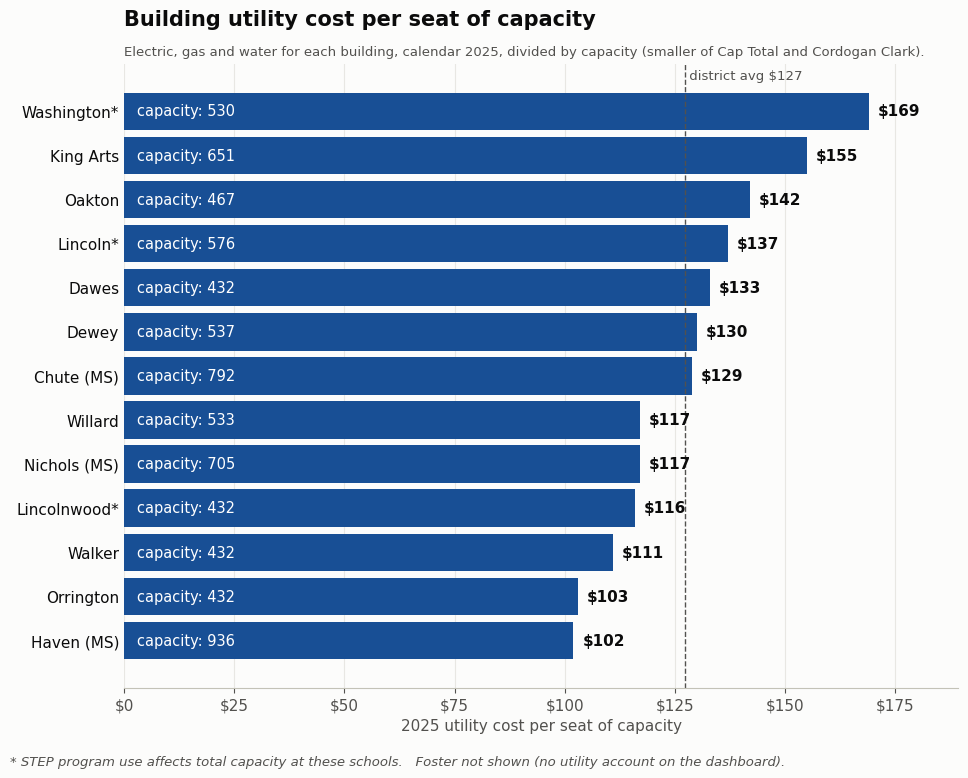

In [26]:
# Chart: 2025 utility cost per seat of capacity (capacity used = smaller of Cap Total and Cordogan)
c = schools_ce.copy()
c['cost_per_seat'] = (c['utility_cost_2025'] / c['capacity_used']).round(0)
c = c.sort_values('cost_per_seat')
c.index = [f'{i}*' if i in STEP else i for i in c.index]
schools_ce['cost_per_seat'] = (schools_ce['utility_cost_2025'] / schools_ce['capacity_used']).round(0)
schools_ce.to_csv('data/utility_cost_per_student.csv')

fig, ax = plt.subplots(figsize=(10, 7.8))
ax.barh(c.index, c['cost_per_seat'], height=0.85, color=DARK_BLUE)
for yi, (cps, capy) in enumerate(c[['cost_per_seat', 'capacity_used']].values):
    ax.text(cps + 2, yi, f'${cps:,.0f}', va='center', fontsize=11, color=INK, fontweight='bold', parse_math=False)
    ax.text(3, yi, f'capacity: {capy:.0f}', va='center', ha='left', fontsize=10.5, color='white')
avg = c.utility_cost_2025.sum() / c.capacity_used.sum()
ax.axvline(avg, color=MUTED, linewidth=1, linestyle='--')
ax.text(avg, len(c) - 0.35, f' district avg ${avg:,.0f}', va='bottom', fontsize=9.5, color=MUTED, parse_math=False)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, c['cost_per_seat'].max() * 1.12)
ax.xaxis.set_major_formatter(lambda v, _: f'${v:,.0f}')
ax.set_xlabel('2025 utility cost per seat of capacity')
ax.set_title('Building utility cost per seat of capacity', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, 'Electric, gas and water for each building, calendar 2025, divided by capacity (smaller of Cap Total and Cordogan Clark).',
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.text(0.01, 0.01, '* STEP program use affects total capacity at these schools.   Foster not shown (no utility account on the dashboard).',
         fontsize=9.5, color=MUTED, style='italic')
fig.savefig('images/chart_utility_cost_per_seat.png', dpi=200)
plt.show()

# 9. Dual-language (TWI) strands — basis for scenarios

A TWI **strand** is one K–5 classroom per grade: 6 rooms, 144 seats at 24 per room (the 1A table's Cap TWI is 144 per strand). Current TWI counts are from the dashboard (TWE/TWS/TWX by school). Grade-level TWI counts aren't on the dashboard, so students per grade assume an even spread.

In [27]:
# Dual-language strands: current TWI students vs. strand capacity (144 seats = 6 rooms per strand)
tw = df[df['chart_id'] == 'home-twi'].pivot_table(index='school', columns='category', values='value', aggfunc='sum')
tw.index = tw.index.map(short)
tw = tw.drop('District', errors='ignore')
u = util.set_index(util['school'].map(short))
tw['twi_now'] = tw[['TWE', 'TWS', 'TWX']].sum(axis=1)
tw['cap_twi'] = u['cap_twi'].reindex(tw.index)
tw['strands'] = (tw['cap_twi'] / 144).astype(int)
tw['rooms'] = tw['strands'] * 6
tw['fill_pct'] = (100 * tw['twi_now'] / tw['cap_twi']).round(0)
tw['per_room'] = (tw['twi_now'] / tw['rooms']).round(1)
tw['tws_share_pct'] = (100 * tw['TWS'] / tw['twi_now']).round(0)
tw['projected_twi'] = u[['enroll_twe', 'enroll_tws', 'enroll_twx']].sum(axis=1).reindex(tw.index)
tw = tw.astype({'TWE': int, 'TWS': int, 'TWX': int, 'twi_now': int, 'cap_twi': int, 'projected_twi': int})
tot = tw[['twi_now', 'cap_twi', 'rooms', 'strands']].sum()
print(f"{tot.twi_now} TWI students in {tot.strands} strands / {tot.rooms} rooms: {tot.twi_now/tot.rooms:.1f} per room, {100*tot.twi_now/tot.cap_twi:.0f}% full")
for target in (0.85, 0.95):
    print(f"Strands needed at {target:.0%} fill: {tot.twi_now / (144*target):.1f}")
tw.to_csv('data/twi_strands.csv')
tw

686 TWI students in 7 strands / 42 rooms: 16.3 per room, 68% full
Strands needed at 85% fill: 5.6
Strands needed at 95% fill: 5.0


category,TWE,TWS,TWX,twi_now,cap_twi,strands,rooms,fill_pct,per_room,tws_share_pct,projected_twi
school,,,,,,,,,,,
Dawes,48,50,16,114,144,1,6,79.0,19.0,44.0,151
Dewey,49,27,26,102,144,1,6,71.0,17.0,26.0,112
Foster,69,75,56,200,288,2,12,69.0,16.7,38.0,197
Oakton,34,24,17,75,144,1,6,52.0,12.5,32.0,87
Washington,90,63,42,195,288,2,12,68.0,16.2,32.0,211


# 10. Estimated classrooms and class size by grade

The dashboard gives enrollment by school and grade, not how many classes each grade is split into, so the number of classes (sections) is **estimated**:

- **Monolingual/mainstream classes:** the fewest classes that keep every class at or under the cap: `ceil(students ÷ cap)`. Real schools sometimes open an extra class, so this is the *fewest* classrooms a grade needs and the *largest* average class size it could have.
- **Dual-language (TWI) schools, K–5:** each strand is one class per grade however many students it has. TWI students are assumed spread evenly across K–5 (grade-level TWI counts aren't published); the rest of the grade forms monolingual/mainstream classes.
- **Middle schools:** students move between rooms for different subjects, so "classes per grade" means sections of about the cap size, not homerooms.
- **The cap:** 24 per class is the district's own capacity standard (Cap Total = 24 × teaching stations). It is **not** the teacher-contract class-size limit; set `CAP` below to D65's actual limits by grade if you have them.
- **Oakton's African-Centered Curriculum (ACC) program:** one ACC class per grade K–5. The dashboard doesn't identify ACC students, so the 1A table's projected 73 ACC students are spread evenly across K–5 (~12 per grade) and removed from Oakton's monolingual/mainstream classes.

In [28]:
# Class-size model: estimate classes per school and grade, then average class size
# Cap per class by grade. 24 = district capacity standard (not the contract limit); change here to test other caps.
CAP = {g: 24 for g in range(9)}     # students per class by grade; edit to D65's limits, e.g. {0: 22, 1: 22, ...}

g = schools[['school', 'grade', 'value']].rename(columns={'value': 'students'}).copy()
g['school'] = g['school'].map(short)
twi_strands = tw['strands']
twi_per_grade = tw['twi_now'] / 6          # even spread across K-5 (assumption)

# Oakton's African-Centered Curriculum (ACC) program: one class per grade K-5. The dashboard doesn't identify ACC students, so use the
# 1A table's projected ACC enrollment (73), spread evenly across K-5, and take them out of Oakton's monolingual/mainstream classes.
ACC_STRANDS = {'Oakton': 1}
acc_total = util.set_index(util['school'].map(short))['enroll_acc']
acc_per_grade = {s: acc_total[s] / 6 for s in ACC_STRANDS}

# Parent-verified class structure (see section 12). At Washington, parents report one monolingual/mainstream class
# alongside the two TWI classes in 2nd grade (23 and 19 students), and departmental classes of 23 in 5th grade. So at
# these schools TWI and monolingual/mainstream students share the cap: the grade gets the fewest classes that keep every
# class at 24 or fewer, with at least one class per TWI strand plus one monolingual/mainstream class. Students are
# spread evenly across those classes (the TWI/mainstream split within a grade isn't known).
POOLED_TWI_SCHOOLS = {'Washington'}

def sections_for(row):
    n, cap, k5 = row.students, CAP[row.grade], row.grade <= 5
    s_twi = int(twi_strands[row.school]) if (row.school in twi_strands.index and k5) else 0
    s_acc = ACC_STRANDS.get(row.school, 0) if k5 else 0
    if s_twi and row.school in POOLED_TWI_SCHOOLS:
        total = max(s_twi + 1, math.ceil(n / cap))
        s_reg = total - s_twi
        t = n * s_twi / total                  # even class sizes across all classes in the grade
        a = 0.0
        rest = n - t
    else:
        t = min(twi_per_grade[row.school], n) if s_twi else 0.0
        a = min(acc_per_grade[row.school], n - t) if s_acc else 0.0
        rest = n - t - a
        s_reg = math.ceil(rest / cap) if rest > 0 else 0
    return pd.Series({'sections': s_twi + s_acc + s_reg,
                      'twi_sections': s_twi, 'twi_students': t, 'twi_class_size': t / s_twi if s_twi else np.nan,
                      'acc_sections': s_acc, 'acc_students': a, 'acc_class_size': a / s_acc if s_acc else np.nan,
                      'mainstream_class_size': rest / s_reg if s_reg else np.nan})

g = g.join(g.apply(sections_for, axis=1))
g['avg_class_size'] = (g['students'] / g['sections']).round(1)

sections_wide = g.pivot_table(index='school', columns='grade', values='sections', aggfunc='sum').astype('Int64')
size_wide = g.pivot_table(index='school', columns='grade', values='avg_class_size', aggfunc='mean').round(1)
sections_wide['total'] = sections_wide.sum(axis=1)

by_grade = g.groupby('grade')[['students', 'sections']].sum()
by_grade['avg_class_size'] = (by_grade['students'] / by_grade['sections']).round(1)
print(f"Estimated {int(by_grade.sections.sum())} classes for {int(by_grade.students.sum())} students "
      f"({by_grade.students.sum() / by_grade.sections.sum():.1f} per class)")
by_grade

Estimated 274 classes for 5462 students (19.9 per class)


,students,sections,avg_class_size
grade,,,
0,534.0,28.0,19.1
1,564.0,32.0,17.6
2,545.0,30.0,18.2
3,606.0,33.0,18.4
4,620.0,31.0,20.0
5,645.0,34.0,19.0
6,603.0,27.0,22.3
7,659.0,29.0,22.7
8,686.0,30.0,22.9


In [29]:
# Estimated classes: school x grade
sections_wide

grade,0,1,2,3,4,5,6,7,8,total
school,,,,,,,,,,
Chute (MS),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,8,9,9,26
Dawes,2,3,2,3,3,3,<NA>,<NA>,<NA>,16
Dewey,3,3,3,3,3,3,<NA>,<NA>,<NA>,18
Foster,3,3,4,4,3,4,<NA>,<NA>,<NA>,21
Haven (MS),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,8,9,9,26
King Arts,2,2,2,3,3,2,2,3,3,22
Lincoln,3,4,3,2,3,3,<NA>,<NA>,<NA>,18
Lincolnwood,2,3,3,2,2,4,<NA>,<NA>,<NA>,16
Nichols (MS),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9,8,9,26


In [30]:
# Estimated average class size: school x grade
size_wide

grade,0,1,2,3,4,5,6,7,8
school,,,,,,,,,
Chute (MS),NaN,NaN,NaN,NaN,NaN,NaN,23.0,23.2,22.0
Dawes,21.5,15.0,21.0,16.0,19.7,17.0,NaN,NaN,NaN
Dewey,16.0,18.3,15.0,17.3,21.3,17.0,NaN,NaN,NaN
Foster,15.3,14.0,16.2,19.8,19.0,18.0,NaN,NaN,NaN
Haven (MS),NaN,NaN,NaN,NaN,NaN,NaN,22.6,23.4,23.6
King Arts,20.5,20.0,18.5,18.7,18.0,23.0,21.5,22.3,20.3
Lincoln,19.0,18.2,17.7,21.5,22.7,18.7,NaN,NaN,NaN
Lincolnwood,24.0,20.0,18.0,21.0,24.0,19.8,NaN,NaN,NaN
Nichols (MS),NaN,NaN,NaN,NaN,NaN,NaN,21.7,21.5,23.9


## Classrooms needed vs. classrooms available

Estimated homeroom classes (elementary) compared with Cordogan Clark's floor-plan classroom count. Art, music, library and small-group rooms aren't homerooms; the Cordogan comments suggest some schools count them among classrooms, so treat the spare number as an upper bound. Middle schools have no Cordogan count.

In [31]:
# Estimated classes vs. Cordogan floor-plan classrooms (spare rooms are an upper bound)
need = sections_wide['total'].rename('classes_needed').to_frame()
need['classrooms'] = rooms_src.rename(index=lambda i: i.rstrip('*')).reindex(need.index)
need['spare_rooms'] = need['classrooms'] - need['classes_needed']
need = need.dropna(subset=['classrooms']).astype('Int64').sort_values('spare_rooms', ascending=False)
print('Spare classrooms (elementary + King Arts, upper bound):', int(need.spare_rooms.sum()))
need.to_csv('data/classrooms_needed_vs_available.csv')
need

Spare classrooms (elementary + King Arts, upper bound): 56


,classes_needed,classrooms,spare_rooms
school,,,
Willard,13,24,11
Lincoln,18,28,10
Dewey,18,24,6
King Arts,22,27,5
Orrington,14,19,5
Washington,19,24,5
Dawes,16,20,4
Foster,21,24,3
Lincolnwood,16,19,3


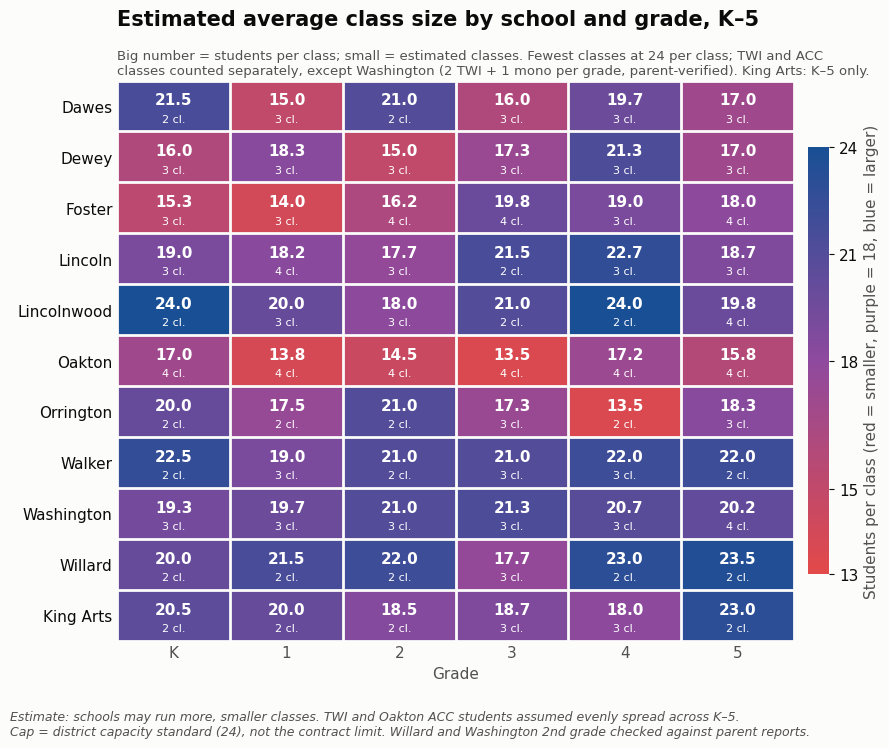

In [32]:
# Heatmap: average class size by school and grade, elementary schools K-5 only (middle schools and King Arts 6-8 left out)
from matplotlib.colors import LinearSegmentedColormap
ramp = LinearSegmentedColormap.from_list('blue_seq', ['#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])
order = ['Dawes', 'Dewey', 'Foster', 'Lincoln', 'Lincolnwood', 'Oakton', 'Orrington', 'Walker', 'Washington', 'Willard',
         'King Arts']
K5 = [0, 1, 2, 3, 4, 5]
H = size_wide.reindex(order)[K5]
S = sections_wide.drop(columns='total').reindex(order)[K5]

fig, ax = plt.subplots(figsize=(9, 7.5))
# Diverging scale: red (small classes) -> purple (18) -> blue (large classes)
from matplotlib.colors import TwoSlopeNorm
MID = 18
vals = H.values.astype(float)
red_blue = LinearSegmentedColormap.from_list('red_purple_blue', [RED, '#8e4a9e', DARK_BLUE])
norm = TwoSlopeNorm(vmin=13, vcenter=MID, vmax=24)
im = ax.imshow(vals, cmap=red_blue, norm=norm, aspect='auto')
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.iat[i, j]
        if pd.notna(v):
            dark = True                     # every color on this scale is dark enough for white text
            ax.text(j, i - 0.12, f'{v:.1f}', ha='center', va='center', fontsize=11, fontweight='bold', color='white' if dark else INK)
            ax.text(j, i + 0.25, f'{int(S.iat[i, j])} cl.', ha='center', va='center', fontsize=8, color='white' if dark else MUTED)
ax.set_xticks(range(6), ['K', '1', '2', '3', '4', '5'])
ax.set_yticks(range(len(order)), order)
ax.tick_params(length=0); ax.grid(False)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xticks(np.arange(-.5, 6, 1), minor=True); ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which='minor', color='#fcfcfb', linewidth=2); ax.tick_params(which='minor', length=0)
ax.set_xlabel('Grade')
ax.set_title('Estimated average class size by school and grade, K–5', loc='left', fontsize=15, fontweight='bold', color=INK, pad=40)
ax.text(0, 1.012, 'Big number = students per class; small = estimated classes. Fewest classes at 24 per class; TWI and ACC\nclasses counted separately, except Washington (2 TWI + 1 mono per grade, parent-verified). King Arts: K–5 only.',
        transform=ax.transAxes, fontsize=9.5, color=MUTED)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cb.outline.set_visible(False)
cb.set_ticks([13, 15, 18, 21, 24]); cb.set_label('Students per class (red = smaller, purple = 18, blue = larger)', color=MUTED)
plt.tight_layout(rect=(0, 0.06, 1, 1))
fig.text(0.01, 0.01, 'Estimate: schools may run more, smaller classes. TWI and Oakton ACC students assumed evenly spread across K–5.\nCap = district capacity standard (24), not the contract limit. Willard and Washington 2nd grade checked against parent reports.',
         fontsize=9, color=MUTED, style='italic')
fig.savefig('images/chart_class_size_heatmap.png', dpi=200)
plt.show()

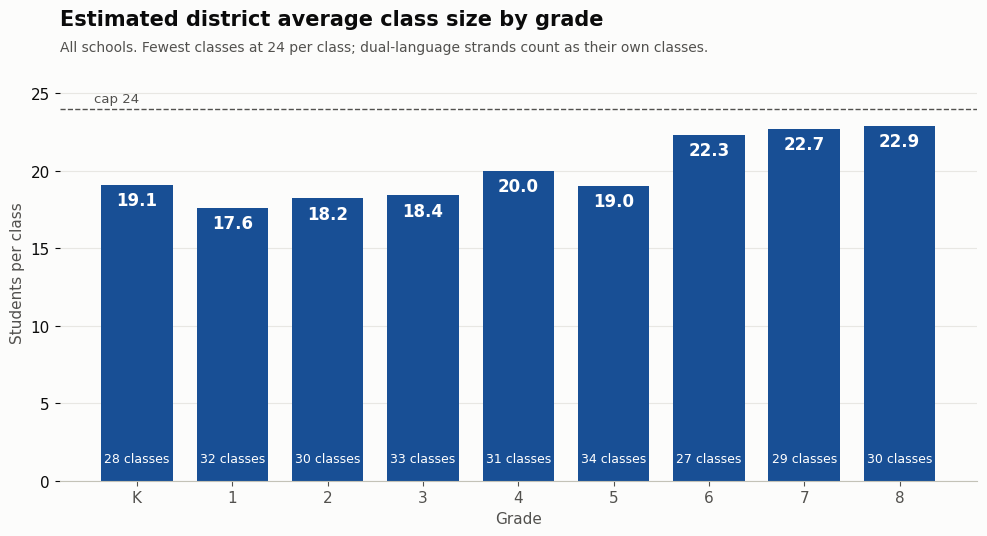

In [33]:
# District average class size by grade
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = ['K', '1', '2', '3', '4', '5', '6', '7', '8']
ax.bar(labels, by_grade['avg_class_size'], width=0.75, color=DARK_BLUE)
for x, (v, s) in enumerate(by_grade[['avg_class_size', 'sections']].values):
    ax.text(x, v - 0.4, f'{v:.1f}', ha='center', va='top', fontsize=12, fontweight='bold', color='white')
    ax.text(x, 1.0, f'{s:.0f} classes', ha='center', va='bottom', fontsize=9, color='white')
ax.grid(axis='x', visible=False); ax.grid(axis='y', visible=True, color='#e8e7e3')
ax.set_ylim(0, 24 * 1.12)
ax.axhline(24, color=MUTED, linewidth=1, linestyle='--')
ax.text(-0.45, 24.2, 'cap 24', ha='left', va='bottom', fontsize=9.5, color=MUTED)
ax.set_xlabel('Grade'); ax.set_ylabel('Students per class')
ax.set_title('Estimated district average class size by grade', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.03, 'All schools. Fewest classes at 24 per class; dual-language strands count as their own classes.',
        transform=ax.transAxes, fontsize=10, color=MUTED)
plt.tight_layout()
fig.savefig('images/chart_class_size_by_grade.png', dpi=200)
plt.show()

## Class size by grade, school by school (with the numbers behind it)

The detail table below shows every input and step for each school and grade, so any estimate can be checked by hand:

- `students`: enrollment in that grade (dashboard, fall SY27)
- `twi_students_est`: dual-language students assumed in that grade (school's TWI total ÷ 6); `twi_sections`: strands at the school (one class per strand per grade)
- `acc_students_est`, `acc_sections`: Oakton only — projected ACC students per grade (73 ÷ 6) in one ACC class per grade
- `mainstream_students`: `students − twi_students_est − acc_students_est`; `mainstream_sections` = `ceil(mainstream_students ÷ cap)`
- `sections` = TWI + ACC + monolingual/mainstream; `avg_class_size` = `students ÷ sections`

**Oakton's ACC program** is modeled as one class per grade K–5 using the projected 73 ACC students (the dashboard doesn't identify current ACC students). If you get the actual ACC count, change `acc_total` for Oakton.

In [34]:
# Detail table: every input and step of the class-size estimate, per school and grade
detail = g.copy()
detail['cap'] = detail['grade'].map(CAP)
detail['twi_students_est'] = detail['twi_students'].round(1)
detail['acc_students_est'] = detail['acc_students'].round(1)
detail['mainstream_students'] = (detail['students'] - detail['twi_students_est'] - detail['acc_students_est']).round(1)
detail['mainstream_sections'] = detail['sections'] - detail['twi_sections'] - detail['acc_sections']
detail['grade_label'] = detail['grade'].map(lambda x: 'K' if x == 0 else str(x))
detail = detail[['school', 'grade', 'grade_label', 'students', 'cap', 'twi_students_est', 'twi_sections', 'twi_class_size',
                 'acc_students_est', 'acc_sections', 'acc_class_size', 'mainstream_students', 'mainstream_sections', 'mainstream_class_size', 'sections', 'avg_class_size']]
detail[['twi_class_size', 'acc_class_size', 'mainstream_class_size']] = detail[['twi_class_size', 'acc_class_size', 'mainstream_class_size']].round(1)
detail = detail.sort_values(['school', 'grade']).reset_index(drop=True)
detail['note'] = np.where(detail['school'] == 'Oakton', '1 ACC class per grade K-5; ACC students = 73 projected (1A table), spread evenly', '')
detail.loc[(detail['school'] == 'Washington') & (detail['grade'] <= 5), 'note'] = (
    'Parent-verified structure: 2 TWI + 1 monolingual/mainstream class per grade (more if needed to stay at 24); '
    'students spread evenly across classes')
detail.to_csv('data/class_size_detail_by_school.csv', index=False)
detail.drop(columns=['grade']).set_index(['school', 'grade_label'])

students  cap  twi_students_est  twi_sections  \
school     grade_label                                                  
Chute (MS) 6               184.0   24               0.0           0.0   
           7               209.0   24               0.0           0.0   
           8               198.0   24               0.0           0.0   
Dawes      K                43.0   24              19.0           1.0   
           1                45.0   24              19.0           1.0   
...                          ...  ...               ...           ...   
Willard    1                43.0   24               0.0           0.0   
           2                44.0   24               0.0           0.0   
           3                53.0   24               0.0           0.0   
           4                46.0   24               0.0           0.0   
           5                47.0   24               0.0           0.0   

                        twi_class_size  acc_students_est  acc_sections  \
school     grade_label                                                   
Chute (MS) 6                       NaN               0.0           0.0   
           7                       NaN               0.0           0.0   
           8                       NaN               0.0           0.0   
Dawes      K                      19.0               0.0           0.0   
           1                      19.0               0.0           0.0   
...                                ...               ...           ...   
Willard    1                       NaN               0.0           0.0   
           2                       NaN               0.0           0.0   
           3                       NaN               0.0           0.0   
           4                       NaN               0.0           0.0   
           5                       NaN               0.0           0.0   

                        acc_class_size  mainstream_students  \
school     grade_label                                        
Chute (MS) 6                       NaN                184.0   
           7                       NaN                209.0   
           8                       NaN                198.0   
Dawes      K                       NaN                 24.0   
           1                       NaN                 26.0   
...                                ...                  ...   
Willard    1                       NaN                 43.0   
           2                       NaN                 44.0   
           3                       NaN                 53.0   
           4                       NaN                 46.0   
           5                       NaN                 47.0   

                        mainstream_sections  mainstream_class_size  sections  \
school     grade_label                                                         
Chute (MS) 6                            8.0                   23.0       8.0   
           7                            9.0                   23.2       9.0   
           8                            9.0                   22.0       9.0   
Dawes      K                            1.0                   24.0       2.0   
           1                            2.0                   13.0       3.0   
...                                     ...                    ...       ...   
Willard    1                            2.0                   21.5       2.0   
           2                            2.0                   22.0       2.0   
           3                            3.0                   17.7       3.0   
           4                            2.0                   23.0       2.0   
           5                            2.0                   23.5       2.0   

                        avg_class_size note  
school     grade_label                       
Chute (MS) 6                      23.0       
           7                      23.2       
           8                      22.0       
Dawes      K        

### Supporting table 1: students by school and grade

Fall SY27 enrollment from the dashboard. Average class size = this table ÷ table 2, cell by cell.

In [35]:
# Supporting table 1: students by school and grade (integers, with totals)
grade_cols = {g: ('K' if g == 0 else str(g)) for g in range(9)}
students_tbl = (detail.pivot_table(index='school', columns='grade', values='students', aggfunc='sum')
                .reindex(order).rename(columns=grade_cols).round().astype('Int64'))
students_tbl['Total'] = students_tbl.sum(axis=1)
students_tbl.loc['All schools'] = students_tbl.sum()
students_tbl.to_csv('data/table_students_by_school_grade.csv')
students_tbl.style.format(na_rep='–')

grade,K,1,2,3,4,5,6,7,8,Total
school,,,,,,,,,,
Dawes,43,45,42,48,59,51,–,–,–,288
Dewey,48,55,45,52,64,51,–,–,–,315
Foster,46,42,65,79,57,72,–,–,–,361
Lincoln,57,73,53,43,68,56,–,–,–,350
Lincolnwood,48,60,54,42,48,79,–,–,–,331
Oakton,68,55,58,54,69,63,–,–,–,367
Orrington,40,35,42,52,27,55,–,–,–,251
Walker,45,57,42,63,66,44,–,–,–,317
Washington,58,59,63,64,62,81,–,–,–,387


### Supporting table 2: estimated classes by school and grade

Fewest classes at 24 per class, plus one class per dual-language strand at each K–5 grade, plus one ACC class per grade at Oakton.

In [36]:
# Supporting table 2: estimated classes by school and grade (integers, with totals)
classes_tbl = (detail.pivot_table(index='school', columns='grade', values='sections', aggfunc='sum')
               .reindex(order).rename(columns=grade_cols).round().astype('Int64'))
classes_tbl['Total'] = classes_tbl.sum(axis=1)
classes_tbl.loc['All schools'] = classes_tbl.sum()
classes_tbl.to_csv('data/table_classes_by_school_grade.csv')
classes_tbl.style.format(na_rep='–')

grade,K,1,2,3,4,5,6,7,8,Total
school,,,,,,,,,,
Dawes,2,3,2,3,3,3,–,–,–,16
Dewey,3,3,3,3,3,3,–,–,–,18
Foster,3,3,4,4,3,4,–,–,–,21
Lincoln,3,4,3,2,3,3,–,–,–,18
Lincolnwood,2,3,3,2,2,4,–,–,–,16
Oakton,4,4,4,4,4,4,–,–,–,24
Orrington,2,2,2,3,2,3,–,–,–,14
Walker,2,3,2,3,3,2,–,–,–,15
Washington,3,3,3,3,3,4,–,–,–,19


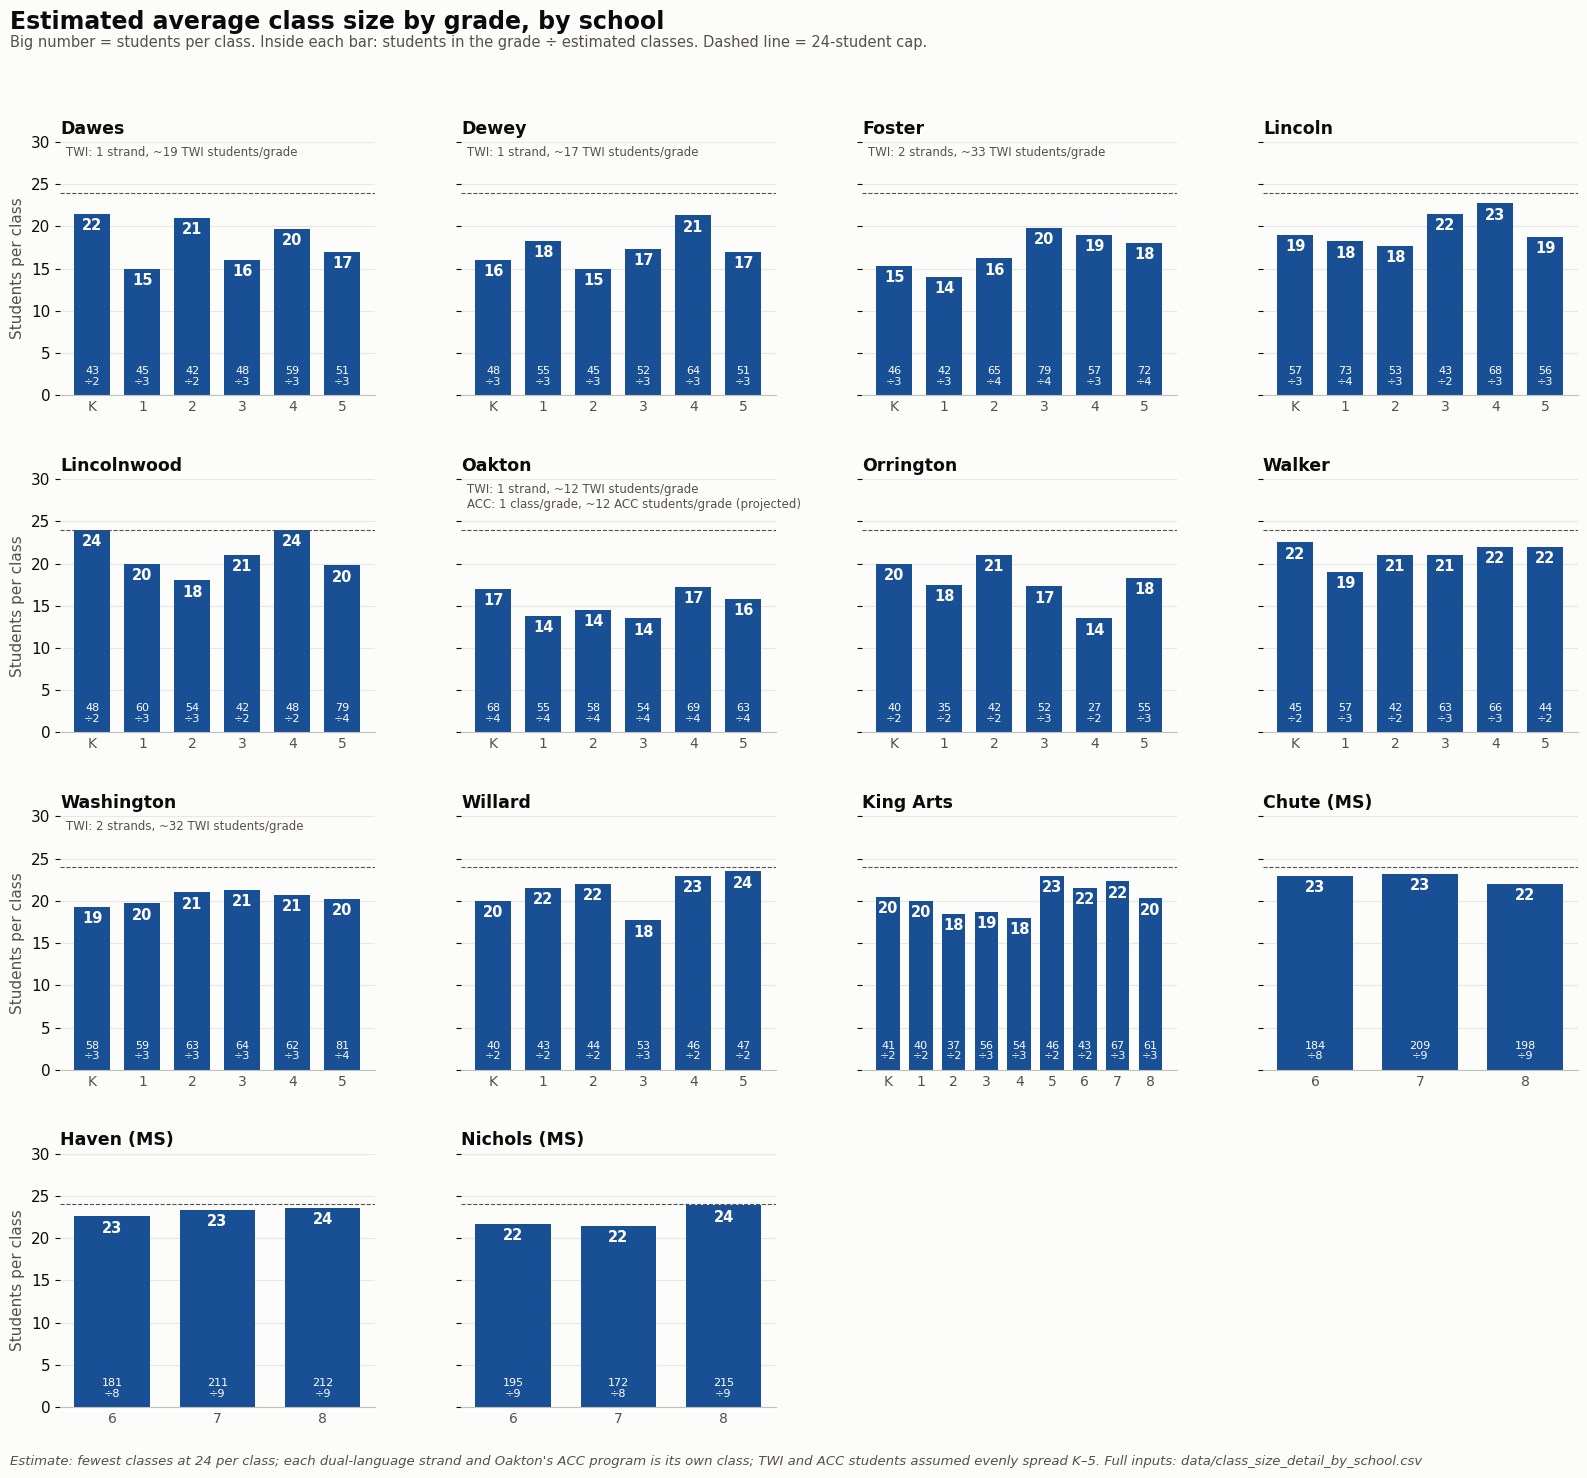

In [37]:
# One small chart per school: average class size per grade, with students and classes under each bar
order = ['Dawes', 'Dewey', 'Foster', 'Lincoln', 'Lincolnwood', 'Oakton', 'Orrington', 'Walker', 'Washington', 'Willard',
         'King Arts', 'Chute (MS)', 'Haven (MS)', 'Nichols (MS)']
fig, axes = plt.subplots(4, 4, figsize=(16, 15), sharey=True)
for ax, school in zip(axes.flat, order):
    d = detail[detail['school'] == school]
    x = np.arange(len(d))
    ax.bar(x, d['avg_class_size'], width=0.72, color=DARK_BLUE)
    for xi, r in zip(x, d.itertuples()):
        ax.text(xi, r.avg_class_size - 0.5, f'{r.avg_class_size:.0f}', ha='center', va='top', fontsize=10.5, fontweight='bold', color='white')
        ax.text(xi, 1.0, f'{r.students:.0f}\n÷{r.sections:.0f}', ha='center', va='bottom', fontsize=8, color='white', linespacing=1.1)
    ax.axhline(24, color=MUTED, linewidth=0.8, linestyle='--')
    ax.set_xticks(x, d['grade_label']); ax.tick_params(axis='x', length=0, labelsize=10)
    ax.grid(axis='x', visible=False); ax.grid(axis='y', color='#e8e7e3')
    ax.set_ylim(0, 30)
    sub = ''
    if school in twi_strands.index:
        n = int(twi_strands[school]); sub = f"TWI: {n} strand{'s' if n > 1 else ''}, ~{twi_per_grade[school]:.0f} TWI students/grade"
    if school == 'Oakton':
        sub += ('\n' if sub else '') + f'ACC: 1 class/grade, ~{acc_per_grade[school]:.0f} ACC students/grade (projected)'
    ax.set_title(school, loc='left', fontsize=12.5, fontweight='bold', color=INK)
    if sub:
        ax.text(0.02, 0.985, sub, transform=ax.transAxes, fontsize=8.5, color=MUTED, va='top', linespacing=1.2)
for ax in axes.flat[len(order):]:
    ax.axis('off')
for ax in axes[:, 0]:
    ax.set_ylabel('Students per class', color=MUTED)
fig.suptitle('Estimated average class size by grade, by school', x=0.01, ha='left', fontsize=17, fontweight='bold', color=INK)
fig.text(0.01, 0.955, 'Big number = students per class. Inside each bar: students in the grade ÷ estimated classes. Dashed line = 24-student cap.',
         fontsize=10.5, color=MUTED)
fig.text(0.01, 0.01, 'Estimate: fewest classes at 24 per class; each dual-language strand and Oakton\'s ACC program is its own class; TWI and ACC students assumed evenly spread K–5. '
         'Full inputs: data/class_size_detail_by_school.csv',
         fontsize=9.5, color=MUTED, style='italic')
plt.tight_layout(rect=(0, 0.025, 1, 0.945), h_pad=2.8)
fig.savefig('images/chart_class_size_by_school.png', dpi=170)
plt.show()

## Elementary class size: by grade for every school, and one number per school

Middle schools (Chute, Haven, Nichols) are excluded. King Arts is K–8, so only its K–5 grades are included.

- **By grade:** each school's estimated average class size in K–5 (same numbers as the school-by-school panels).
- **By school:** the **average of the grade averages**, with each grade counting equally regardless of size. The student-weighted average (all students ÷ all classes) is in the table for comparison.

In [38]:
# Elementary only (King Arts K-5): average of grade averages and student-weighted average per school
elem = detail[~detail['school'].str.contains('MS') & (detail['grade'] <= 5)].copy()

school_avg = elem.groupby('school').agg(avg_of_grade_avgs=('avg_class_size', 'mean'),
                                        students=('students', 'sum'), classes=('sections', 'sum'))
school_avg['weighted_avg'] = school_avg['students'] / school_avg['classes']
school_avg = school_avg.round(1).sort_values('avg_of_grade_avgs')
school_avg.to_csv('data/class_size_by_school_overall.csv')
school_avg

,avg_of_grade_avgs,students,classes,weighted_avg
school,,,,
Oakton,15.3,367.0,24.0,15.3
Foster,17.0,361.0,21.0,17.2
Dewey,17.5,315.0,18.0,17.5
Orrington,17.9,251.0,14.0,17.9
Dawes,18.4,288.0,16.0,18.0
Lincoln,19.6,350.0,18.0,19.4
King Arts,19.8,274.0,14.0,19.6
Washington,20.4,387.0,19.0,20.4
Lincolnwood,21.1,331.0,16.0,20.7


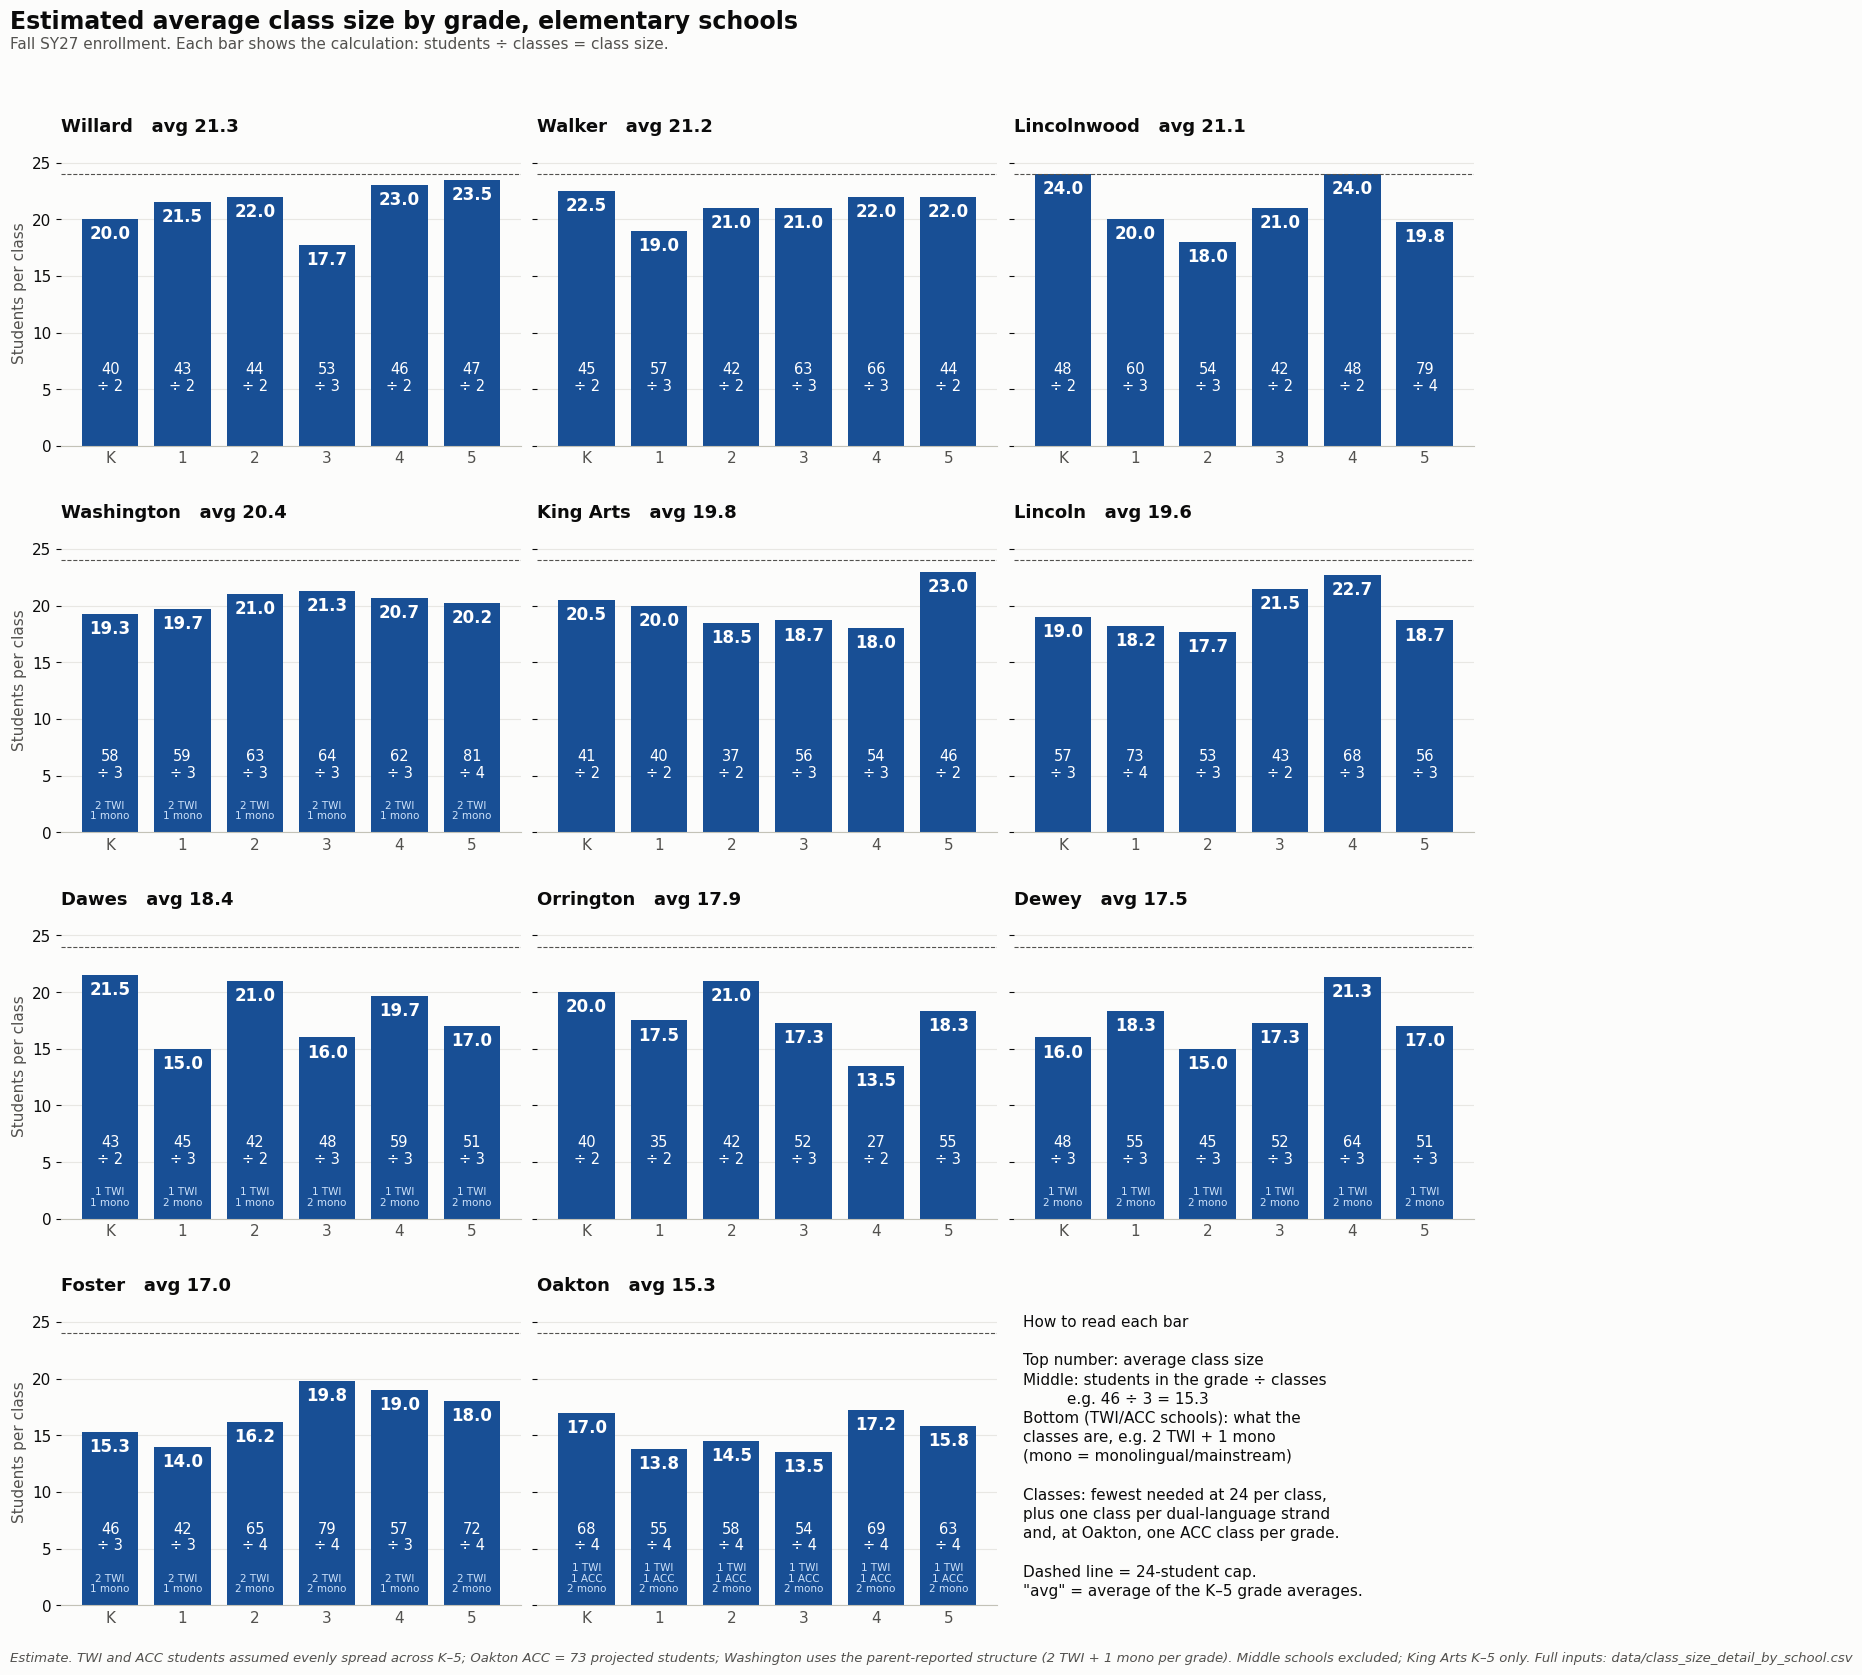

In [39]:
# Graph 1: one panel per elementary school, the math written in every bar
sch_order = school_avg.index.tolist()[::-1]          # largest average first, same order as graph 2
fig, axes = plt.subplots(4, 3, figsize=(15, 17), sharey=True)
for ax, school in zip(axes.flat, sch_order):
    d = elem[elem['school'] == school].sort_values('grade')
    x = np.arange(len(d))
    ax.bar(x, d['avg_class_size'], width=0.78, color=DARK_BLUE)
    for xi, r in zip(x, d.itertuples()):
        ax.text(xi, r.avg_class_size - 0.5, f'{r.avg_class_size:.1f}', ha='center', va='top',
                fontsize=12, fontweight='bold', color='white')
        # the calculation: students in the grade ÷ classes
        ax.text(xi, 4.6, f'{r.students:.0f}\n÷ {r.sections:.0f}', ha='center', va='bottom',
                fontsize=10.5, color='white', linespacing=1.15)
        # what the classes are made of
        parts = []
        if r.twi_sections: parts.append(f'{r.twi_sections:.0f} TWI')
        if r.acc_sections: parts.append(f'{r.acc_sections:.0f} ACC')
        if parts:
            parts.append(f'{r.mainstream_sections:.0f} mono')
            ax.text(xi, 1.0, '\n'.join(parts), ha='center', va='bottom', fontsize=7.5, color='#cde2fb', linespacing=1.1)
    ax.axhline(24, color=MUTED, linewidth=0.8, linestyle='--')
    ax.set_xticks(x, d['grade_label']); ax.tick_params(axis='x', length=0, labelsize=11)
    ax.grid(axis='x', visible=False); ax.grid(axis='y', color='#e8e7e3')
    ax.set_ylim(0, 27)
    ax.set_title(f"{school}   avg {school_avg.loc[school, 'avg_of_grade_avgs']:.1f}", loc='left',
                 fontsize=13, fontweight='bold', color=INK)
for ax in axes[:, 0]:
    ax.set_ylabel('Students per class', color=MUTED)

# last panel: how to read it
key = axes.flat[len(sch_order)]
key.axis('off')
key.text(0.02, 0.95,
         "How to read each bar\n\n"
         "Top number: average class size\n"
         "Middle: students in the grade ÷ classes\n"
         "         e.g. 46 ÷ 3 = 15.3\n"
         "Bottom (TWI/ACC schools): what the\n"
         "classes are, e.g. 2 TWI + 1 mono\n(mono = monolingual/mainstream)\n\n"
         "Classes: fewest needed at 24 per class,\n"
         "plus one class per dual-language strand\n"
         "and, at Oakton, one ACC class per grade.\n\n"
         "Dashed line = 24-student cap.\n"
         "\"avg\" = average of the K–5 grade averages.",
         transform=key.transAxes, va='top', fontsize=11, color=INK, linespacing=1.35)

fig.suptitle('Estimated average class size by grade, elementary schools', x=0.01, ha='left',
             fontsize=17, fontweight='bold', color=INK)
fig.text(0.01, 0.957, 'Fall SY27 enrollment. Each bar shows the calculation: students ÷ classes = class size.',
         fontsize=11, color=MUTED)
fig.text(0.01, 0.008, 'Estimate. TWI and ACC students assumed evenly spread across K–5; Oakton ACC = 73 projected students; Washington uses the parent-reported structure (2 TWI + 1 mono per grade). '
         'Middle schools excluded; King Arts K–5 only. Full inputs: data/class_size_detail_by_school.csv',
         fontsize=9.5, color=MUTED, style='italic')
plt.tight_layout(rect=(0, 0.02, 1, 0.95), h_pad=2.5)
fig.savefig('images/chart_class_size_elementary_by_grade.png', dpi=170)
plt.show()

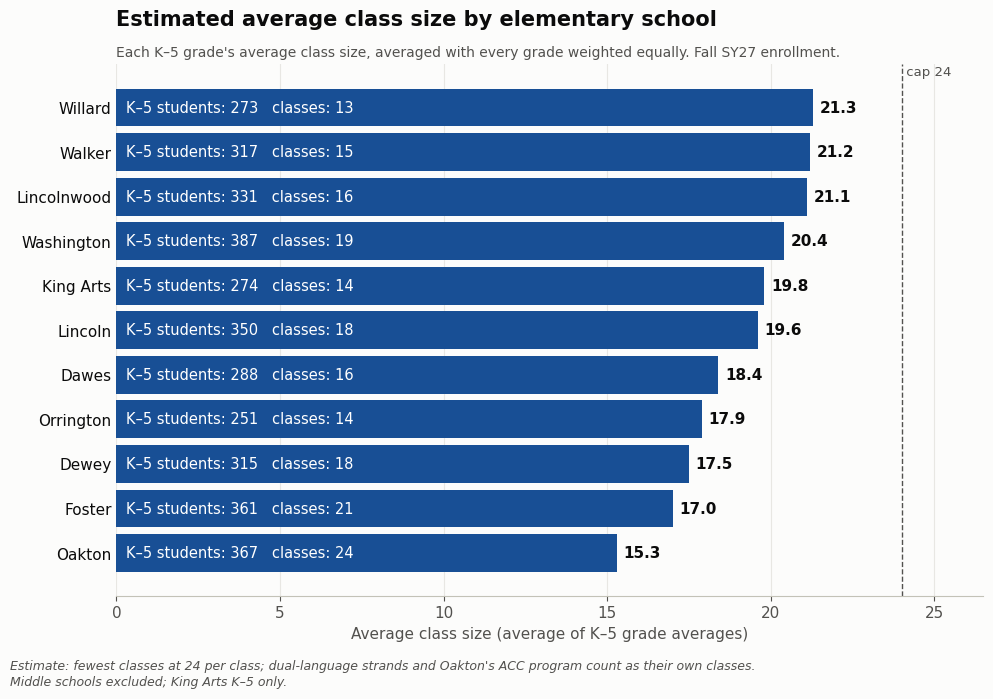

In [40]:
# Graph 2: one number per school (average of its K-5 grade averages)
sa = school_avg
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(sa.index, sa['avg_of_grade_avgs'], height=0.85, color=DARK_BLUE)
for yi, (v, n, k) in enumerate(sa[['avg_of_grade_avgs', 'students', 'classes']].values):
    ax.text(v + 0.2, yi, f'{v:.1f}', va='center', fontsize=11, color=INK, fontweight='bold')
    ax.text(0.3, yi, f'K–5 students: {n:.0f}   classes: {k:.0f}', va='center', ha='left', fontsize=10.5, color='white')
ax.axvline(24, color=MUTED, linewidth=1, linestyle='--')
ax.text(24, len(sa) - 0.35, ' cap 24', va='bottom', fontsize=9.5, color=MUTED)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, 26.5)
ax.set_xlabel('Average class size (average of K–5 grade averages)')
ax.set_title('Estimated average class size by elementary school', loc='left', fontsize=15, fontweight='bold', color=INK, pad=28)
ax.text(0, 1.015, "Each K–5 grade's average class size, averaged with every grade weighted equally. Fall SY27 enrollment.",
        transform=ax.transAxes, fontsize=10, color=MUTED)
plt.tight_layout(rect=(0, 0.05, 1, 1))
fig.text(0.01, 0.01, 'Estimate: fewest classes at 24 per class; dual-language strands and Oakton\'s ACC program count as their own classes.\n'
         'Middle schools excluded; King Arts K–5 only.', fontsize=9, color=MUTED, style='italic', linespacing=1.3)
fig.savefig('images/chart_class_size_by_school_overall.png', dpi=200)
plt.show()

# 11. Enrollment by school and grade, with dual-language breakouts

Elementary schools (King Arts K–5 only).

- **Total:** fall SY27 enrollment from the dashboard.
- **TWI (est.):** the school's actual dual-language total (dashboard TWE + TWS + TWX), spread evenly across K–5. The dashboard doesn't publish TWI by grade. Each estimate is rounded to a whole student so the row adds up to the school's real TWI total.
- **ACC (est.):** Oakton only. The 73 projected ACC students (1A table), spread the same way.
- **Mono/mainstream:** monolingual/mainstream students = Total minus the breakouts.
- **Strands:** one dual-language class per grade for each strand (Cap TWI ÷ 144).

In [41]:
# Enrollment table with TWI (and Oakton ACC) breakouts; estimates are whole students that add up to real totals
def spread_evenly(total, n=6):
    """Split a whole number across n grades as evenly as possible (largest remainder), so the parts add up to total."""
    base = [total // n] * n
    for i in range(int(total - sum(base))):
        base[i] += 1
    return base

GR = ['K', '1', '2', '3', '4', '5']
elem_students = (elem.pivot_table(index='school', columns='grade', values='students', aggfunc='sum')
                 .reindex(sorted(elem['school'].unique())).astype(int))
elem_students.columns = GR

rows = []
for school, tot in elem_students.iterrows():
    rows.append({'school': school, 'row': 'Total', **tot.to_dict(), 'Total': tot.sum(), 'strands': ''})
    remaining = tot.copy()
    if school in twi_strands.index:
        twi = pd.Series(spread_evenly(int(tw.loc[school, 'twi_now'])), index=GR)
        remaining -= twi
        rows.append({'school': school, 'row': 'TWI (est.)', **twi.to_dict(), 'Total': twi.sum(), 'strands': int(twi_strands[school])})
    if school in ACC_STRANDS:
        acc = pd.Series(spread_evenly(int(acc_total[school])), index=GR)
        remaining -= acc
        rows.append({'school': school, 'row': 'ACC (est.)', **acc.to_dict(), 'Total': acc.sum(), 'strands': ''})
    if len(rows) and rows[-1]['school'] == school and rows[-1]['row'] != 'Total':
        rows.append({'school': school, 'row': 'Mono/mainstream',
                     **remaining.to_dict(), 'Total': remaining.sum(), 'strands': ''})

enr_tbl = pd.DataFrame(rows)
all_tot = elem_students.sum()
twi_all = enr_tbl[enr_tbl['row'] == 'TWI (est.)'][GR].sum()
enr_tbl = pd.concat([enr_tbl, pd.DataFrame([
    {'school': 'All elementary', 'row': 'Total', **all_tot.to_dict(), 'Total': all_tot.sum(), 'strands': ''},
    {'school': 'All elementary', 'row': 'TWI (est.)', **twi_all.to_dict(), 'Total': twi_all.sum(),
     'strands': int(twi_strands.sum())}])], ignore_index=True)
enr_tbl[GR + ['Total']] = enr_tbl[GR + ['Total']].astype(int)
enr_tbl.to_csv('data/table_enrollment_twi_by_school_grade.csv', index=False)
enr_tbl.set_index(['school', 'row'])

K    1    2    3    4    5  Total strands
school         row                                                         
Dawes          Total             43   45   42   48   59   51    288        
               TWI (est.)        19   19   19   19   19   19    114       1
               Mono/mainstream   24   26   23   29   40   32    174        
Dewey          Total             48   55   45   52   64   51    315        
               TWI (est.)        17   17   17   17   17   17    102       1
               Mono/mainstream   31   38   28   35   47   34    213        
Foster         Total             46   42   65   79   57   72    361        
               TWI (est.)        34   34   33   33   33   33    200       2
               Mono/mainstream   12    8   32   46   24   39    161        
King Arts      Total             41   40   37   56   54   46    274        
Lincoln        Total             57   73   53   43   68   56    350        
Lincolnwood    Total             48   60   54   42   48   79    331        
Oakton         Total             68   55   58   54   69   63    367        
               TWI (est.)        13   13   13   12   12   12     75       1
               ACC (est.)        13   12   12   12   12   12     73        
               Mono/mainstream   42   30   33   30   45   39    219        
Orrington      Total             40   35   42   52   27   55    251        
Walker         Total             45   57   42   63   66   44    317        
Washington     Total             58   59   63   64   62   81    387        
               TWI (est.)        33   33   33   32   32   32    195       2
               Mono/mainstream   25   26   30   32   30   49    192        
Willard        Total             40   43   44   53   46   47    273        
All elementary Total            534  564  545  606  620  645   3514        
               TWI (est.)       116  116  115  113  113  113    686       7

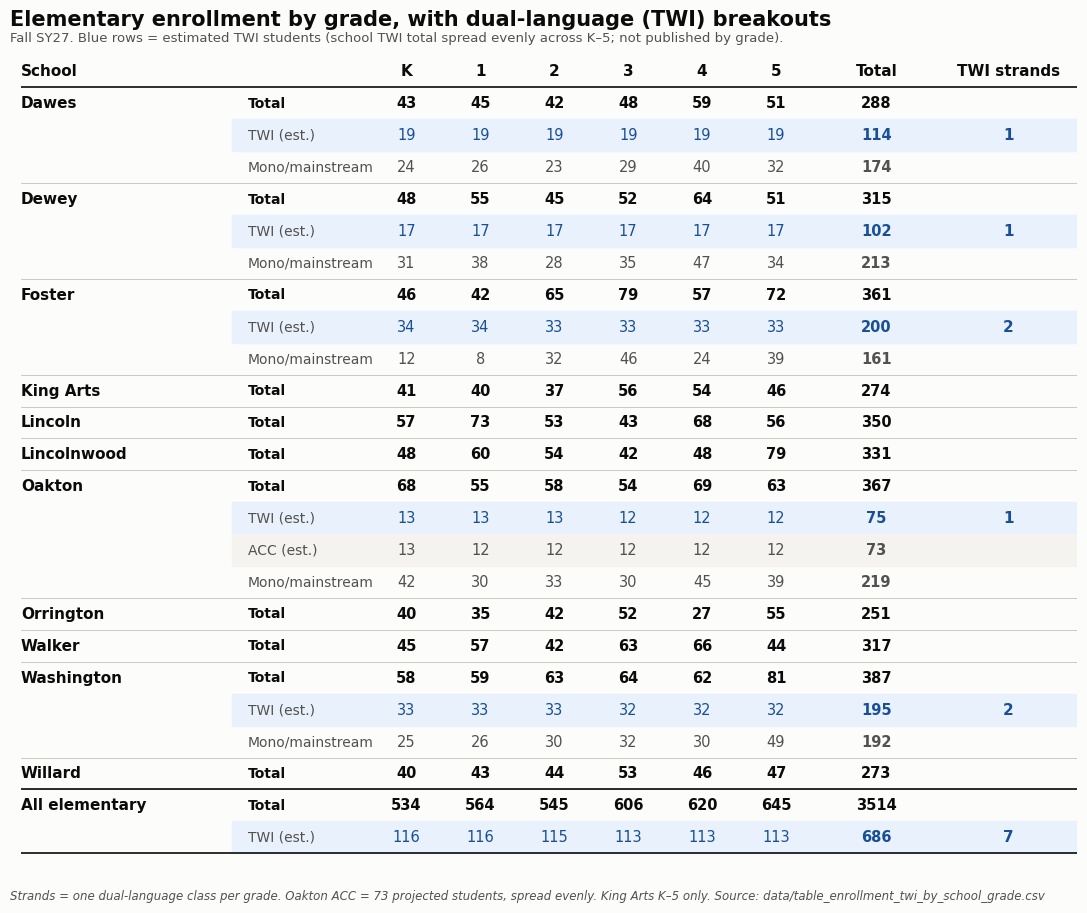

In [42]:
# Draw it as a clean table image
cols = ['School', ''] + GR + ['Total', 'TWI strands']
col_x = [0.0, 0.215, 0.33, 0.40, 0.47, 0.54, 0.61, 0.68, 0.775, 0.90]
n = len(enr_tbl)
row_h = 1 / (n + 1.6)
fig, ax = plt.subplots(figsize=(11, 0.34 * (n + 3)))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

def y_of(i):            # i = 0 is the header
    return 1 - (i + 0.5) * row_h

# header
for x, c in zip(col_x, cols):
    ax.text(x + (0.035 if x >= 0.33 else 0), y_of(0), c, ha='center' if x >= 0.33 else 'left', va='center',
            fontsize=11, fontweight='bold', color=INK)
ax.plot([0, 1], [1 - row_h, 1 - row_h], color=INK, linewidth=1.2)

prev_school = None
for i, r in enumerate(enr_tbl.itertuples(index=False), start=1):
    if r.school != prev_school:
        prev_school = r.school
        if i > 1:
            ax.plot([0, 1], [1 - i * row_h, 1 - i * row_h], color='#c3c2b7', linewidth=0.6)
    y = y_of(i)
    is_total = r.row == 'Total'
    is_all = r.school == 'All elementary'
    bg = '#e8f1fc' if r.row == 'TWI (est.)' else ('#f4f3f0' if r.row == 'ACC (est.)' else None)
    if bg:
        ax.add_patch(plt.Rectangle((0.2, y - row_h / 2), 0.8, row_h, color=bg, zorder=0))
    if is_total:
        ax.text(0.0, y, r.school, ha='left', va='center', fontsize=11, fontweight='bold', color=INK)
    ax.text(0.215, y, r.row, ha='left', va='center', fontsize=10, color=INK if is_total else MUTED,
            fontweight='bold' if is_total else 'normal')
    for k, g_ in enumerate(GR):
        v = enr_tbl.iloc[i - 1][g_]
        ax.text(col_x[2 + k] + 0.035, y, f'{v}', ha='center', va='center', fontsize=10.5,
                color=INK if is_total else (DARK_BLUE if r.row == 'TWI (est.)' else MUTED),
                fontweight='bold' if is_total else 'normal')
    ax.text(col_x[8] + 0.035, y, f'{r.Total}', ha='center', va='center', fontsize=10.5,
            color=INK if is_total else (DARK_BLUE if r.row == 'TWI (est.)' else MUTED), fontweight='bold')
    if r.strands != '':
        ax.text(col_x[9] + 0.035, y, f'{r.strands}', ha='center', va='center', fontsize=11, fontweight='bold', color=DARK_BLUE)
    if is_all and is_total:
        ax.plot([0, 1], [1 - i * row_h, 1 - i * row_h], color=INK, linewidth=1.2)
ax.plot([0, 1], [1 - (n + 1) * row_h, 1 - (n + 1) * row_h], color=INK, linewidth=1.2)

fig.suptitle('Elementary enrollment by grade, with dual-language (TWI) breakouts', x=0.01, ha='left',
             fontsize=15, fontweight='bold', color=INK)
fig.text(0.01, 0.945, 'Fall SY27. Blue rows = estimated TWI students (school TWI total spread evenly across K–5; not published by grade).',
         fontsize=9.5, color=MUTED)
fig.text(0.01, 0.01, 'Strands = one dual-language class per grade. Oakton ACC = 73 projected students, spread evenly. King Arts K–5 only. '
         'Source: data/table_enrollment_twi_by_school_grade.csv', fontsize=8.5, color=MUTED, style='italic')
plt.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.04)
fig.savefig('images/table_enrollment_twi_by_school_grade.png', dpi=200)
plt.show()

# 12. Parent-reported class sizes: checking the estimates

The class sizes in section 10 are **estimates**: the dashboard reports students by grade, not by class, so we assumed the fewest classes that keep every class at 24 or fewer (with TWI and ACC classes counted separately).

Parents have started reporting actual class sizes through the project's [crowdsourcing form](https://docs.google.com/forms/d/e/1FAIpQLSepZPKRXOA8HTbEoWf8sUmXK_UlhWkK4_6y4cl9NQLNEYL1Bw/viewform?usp=dialog). Those reports are in `data/parent_reported_class_sizes.csv` (one row per form response, as submitted, minus one response that contained no class data). Here we:

1. **Combine duplicate reports** of the same class (same school, grade, program and teacher). If reports disagree we keep the median and note it.
2. **Compare each reported class with our estimate** for that school, grade and program (monolingual/mainstream or TWI).
3. Label each class **Consistent** (within 2 students of the estimate) or **Differs**.

**What counts as verified.** A class is *parent-verified* when a parent reported it with confidence 4 or 5 (out of 5) and named the source (teacher, conference, class list, etc.). These are still second-hand reports, not district data. Reports cover **Willard (all six grades)** and **Washington (2nd and 5th grade)** so far; every other school and grade is still an estimate only.

In [43]:
# --- Parent reports: combine duplicates ------------------------------------------
reports = pd.read_csv("data/parent_reported_class_sizes.csv", dtype={"grade": str})
reports["program"] = reports["program"].fillna("Monolingual/mainstream")

classes_reported = (reports
    .groupby(["school", "grade", "program", "teacher"], as_index=False)
    .agg(reported_class_size=("reported_class_size", "median"),
         n_reports=("reported_class_size", "size"),
         reports_agree=("reported_class_size", lambda s: s.nunique() == 1),
         max_confidence=("confidence_1to5", "max"),
         reported_grade_total=("reported_grade_total", "max"),
         sources=("source_note", lambda s: "; ".join(sorted(set(s.dropna())))))
)
classes_reported["parent_verified"] = (classes_reported["max_confidence"] >= 4) & (classes_reported["sources"] != "")

# --- Our estimate for the same school / grade / program ----------------------------
est = pd.read_csv("data/class_size_detail_by_school.csv", dtype={"grade_label": str})
est = est.drop(columns="grade").rename(columns={"grade_label": "grade"})  # use K,1..5 labels

def estimate_for(row):
    e = est[(est["school"] == row["school"]) & (est["grade"] == row["grade"])].iloc[0]
    if row["program"] == "TWI":
        return e["twi_class_size"], e["twi_sections"], "TWI"
    if row["program"].startswith("Departmental"):
        return e["avg_class_size"], e["sections"], "all classes (departmental)"
    return e["mainstream_class_size"], e["mainstream_sections"], "monolingual/mainstream"

classes_reported[["estimated_class_size", "estimated_classes", "compared_with"]] = (
    classes_reported.apply(lambda r: pd.Series(estimate_for(r)), axis=1))
classes_reported["difference"] = (classes_reported["reported_class_size"]
                                  - classes_reported["estimated_class_size"]).round(1)
classes_reported["status"] = np.where(classes_reported["difference"].abs() <= 2, "Consistent", "Differs")

grade_order = {g: i for i, g in enumerate(["K", "1", "2", "3", "4", "5"])}
classes_reported = classes_reported.sort_values(["school", "grade", "program", "teacher"],
                                                key=lambda s: s.map(grade_order) if s.name == "grade" else s)
classes_reported.to_csv("data/class_size_parent_check.csv", index=False)

cols = ["school", "grade", "program", "teacher", "reported_class_size", "n_reports", "max_confidence",
        "parent_verified", "estimated_class_size", "difference", "status"]
classes_reported[cols].style.format({"reported_class_size": "{:.0f}", "estimated_class_size": "{:.1f}",
                                     "difference": "{:+.1f}", "max_confidence": "{:.0f}"}).hide(axis="index")

school,grade,program,teacher,reported_class_size,n_reports,max_confidence,parent_verified,estimated_class_size,difference,status
Washington,2,Monolingual/mainstream,Kincaid-McGehee,23,1,5,True,21.0,+2.0,Consistent
Washington,2,TWI,Salaiza,19,1,5,True,21.0,-2.0,Consistent
Washington,5,Departmental (gen ed and TWI),Del / Howard,23,1,5,True,20.2,+2.8,Differs
Willard,K,Monolingual/mainstream,Davis,20,1,5,True,20.0,+0.0,Consistent
Willard,1,Monolingual/mainstream,Trafman,21,2,5,True,21.5,-0.5,Consistent
Willard,1,Monolingual/mainstream,Zuravel,22,1,nan,False,21.5,+0.5,Consistent
Willard,2,Monolingual/mainstream,Chau,22,1,5,True,22.0,+0.0,Consistent
Willard,2,Monolingual/mainstream,Fowler,21,3,5,True,22.0,-1.0,Consistent
Willard,3,Monolingual/mainstream,Collins,19,1,4,True,17.7,+1.3,Consistent
Willard,4,Monolingual/mainstream,Johnston,23,1,5,True,23.0,+0.0,Consistent


## Grade-level check: reported classes vs. dashboard enrollment

For each school and grade with reports: how many classes parents reported, how many we estimated, the sum of the reported class sizes, and the dashboard's enrollment for that grade. When every class in a grade has been reported, the sum should match the dashboard.

In [44]:
grade_check = (classes_reported
    .groupby(["school", "grade"], as_index=False)
    .agg(classes_reported=("teacher", "size"),
         sum_of_reported_sizes=("reported_class_size", "sum"),
         parent_grade_total=("reported_grade_total", "max")))
est_grade = est[["school", "grade", "students", "sections", "avg_class_size"]].rename(
    columns={"students": "dashboard_students", "sections": "estimated_classes",
             "avg_class_size": "estimated_avg_class_size"})
grade_check = grade_check.merge(est_grade, on=["school", "grade"], how="left")
grade_check["all_classes_reported"] = grade_check["classes_reported"] >= grade_check["estimated_classes"]
grade_check = grade_check.sort_values(["school", "grade"], key=lambda s: s.map(grade_order) if s.name == "grade" else s)
grade_check.to_csv("data/class_size_parent_check_by_grade.csv", index=False)
grade_check.style.format({c: "{:.0f}" for c in ["sum_of_reported_sizes", "parent_grade_total", "dashboard_students",
                                                "estimated_classes"]} | {"estimated_avg_class_size": "{:.1f}"},
                         na_rep="—").hide(axis="index")

school,grade,classes_reported,sum_of_reported_sizes,parent_grade_total,dashboard_students,estimated_classes,estimated_avg_class_size,all_classes_reported
Washington,2,2,42,—,63,3,21.0,False
Washington,5,1,23,—,81,4,20.2,False
Willard,K,1,20,—,40,2,20.0,False
Willard,1,2,43,43,43,2,21.5,True
Willard,2,2,43,42,44,2,22.0,True
Willard,3,1,19,—,53,3,17.7,False
Willard,4,1,23,—,46,2,23.0,False
Willard,5,1,25,—,47,2,23.5,False
